In [1]:
import uproot
import pandas as pd
import numpy as np
import json
import dill
from scipy.optimize import curve_fit, minimize
from scipy.stats import argus
from scipy.integrate import quad
from numpy import  log, sqrt, exp, pi, e
import multiprocessing
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
from numba import njit
from source import *
plt.rcParams['text.usetex'] = True


In [2]:
path = lambda x: f"/home/mar/Documents/NIR/img/{x}"

In [3]:
# Function to process each CSV file and return it as a DataFrame
def process_file(filename):
    if 'csv' in filename:
        try:
            filepath = os.path.join("inc_mc", filename)
            inc = pd.read_csv(filepath)  # Read the CSV file into a DataFrame
            inc['source_file'] = filename  # Add source file info for tracking
            print(f"Processing {filename}")
            return inc
        except Exception as e:
            print(f"Failed to process {filename}: {e}")

# Main function to execute parallel processing and concatenate results
def mk_pddf():
    combined_df = pd.DataFrame()  # Initialize an empty DataFrame to accumulate results
    with ThreadPoolExecutor() as executor:
        futures = [executor.submit(process_file, filename) for filename in os.listdir("inc_mc") if filename.endswith('.csv')]
        for future in as_completed(futures):
            df = future.result()
            if df is not None:
                combined_df = pd.concat([combined_df, df], ignore_index=True)
    
    print("Combined DataFrame created.")
    return combined_df
inc = mk_pddf()


Processing 6.csv
Processing 5.csv
Processing 3.csv
Processing 4.csv
Combined DataFrame created.


In [4]:
output_dir = "output"
pdf_dir = os.path.join(output_dir, "pdfs")
params_dir = os.path.join(output_dir, "params")
bounds_dir = os.path.join(output_dir, "bounds")

os.makedirs(pdf_dir, exist_ok=True)
os.makedirs(params_dir, exist_ok=True)
os.makedirs(bounds_dir, exist_ok=True)

In [5]:
inc.head()

,__experiment__,__run__,__event__,__production__,__candidate__,__ncandidates__,__weight__,pcm,ecm,recM,...,ach_first_dt_chan,isPiFromLc,isPFromLc,charge,LambdaQ,IsS0,IsS1,IsS2,totalEnergyMC,source_file
0,61,24,1552,0,0,1,1.0,3.016362,6.350488,2.961385,...,NaN,0.0,0.0,1.0,1.0,0.0,1.0,1.0,22.995047,6.csv
1,61,24,2271,0,0,1,1.0,0.710477,8.037351,2.438841,...,NaN,NaN,0.0,-1.0,NaN,1.0,0.0,NaN,22.944744,6.csv
2,61,24,3851,0,0,3,1.0,2.874635,7.350382,1.466707,...,NaN,0.0,0.0,-1.0,NaN,1.0,0.0,1.0,22.998529,6.csv
3,61,24,3851,0,1,3,1.0,2.710153,7.237675,1.951917,...,NaN,0.0,0.0,-1.0,NaN,1.0,0.0,1.0,22.998529,6.csv
4,61,24,3851,0,2,3,1.0,2.646612,7.210526,2.081452,...,NaN,0.0,0.0,-1.0,NaN,1.0,0.0,0.0,22.998529,6.csv


In [6]:
inc['vphoE'] = inc['totalEnergyMC'] 

In [7]:
inc['IsS'] = (inc.IsS0 == 1) & (inc.IsS1 == 1) & ((inc.IsS2 == 1) | (inc.idec.isin([2, 3]))) 
inc['LC_miss'] = (inc.IsSignalXc == 1) & ((inc.isPiFromLc == 0) | (inc.idec.isin([2, 3])))

In [8]:
decay_mod_taging = ["$X_c = D^+ p \\pi^- $", "$X_c = D^0 p$", "$X_c = D^{*0} p$", "$X_c = D^{*+} p \\pi^-$"]
decay_mod_tag = {"\\Lambda \\nu_l l": [lambda x: x <= 2, "L_nu_l"], "\\Lambda \\pi" : [lambda x: x == 3, "L_pi"], "p K \\pi" : [lambda x: x == 5, "p_k_pi"]}

In [9]:
wbin = 0.02
a = 1.6
b = 2.5
bins = np.linspace(a, b, int((b-a)/wbin))


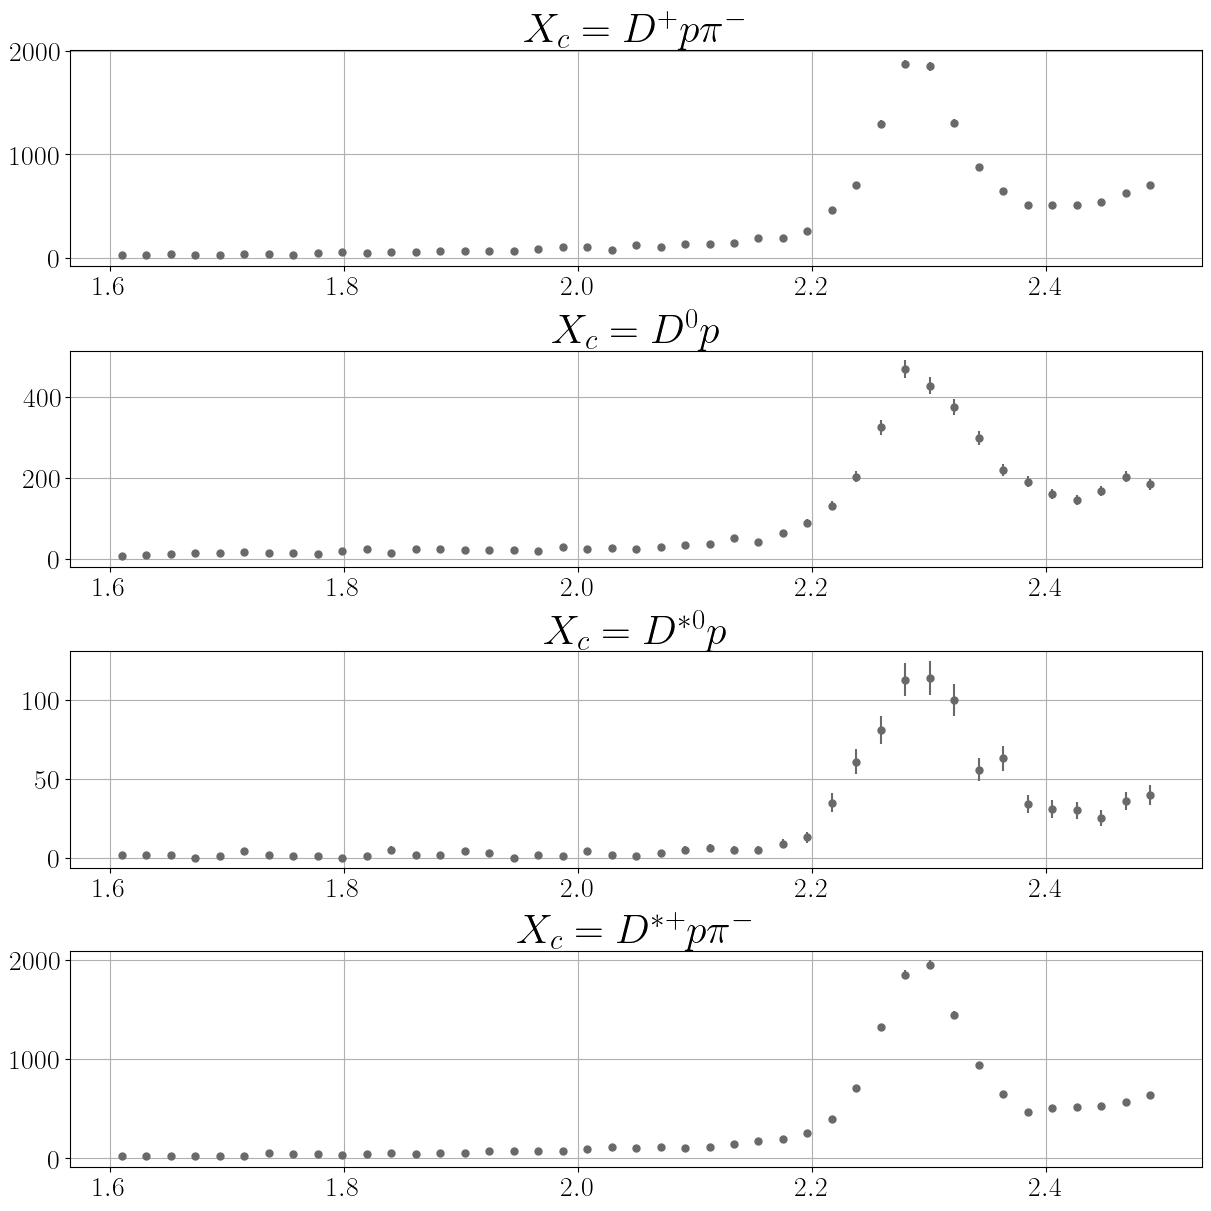

In [ ]:


fig, axs = plt.subplots(4, figsize=(12, 12))
for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i) & (inc.IsSignalXc == 1) & (inc.IsS == 1)]
    N = dat.shape[0]
    counts, bin_centers = errorhist(dat.recM, bins=bins, axs = axs[ind])
    axs[ind].set_title(decay_mod_taging[ind])    
    axs[ind].grid()

plt.show()

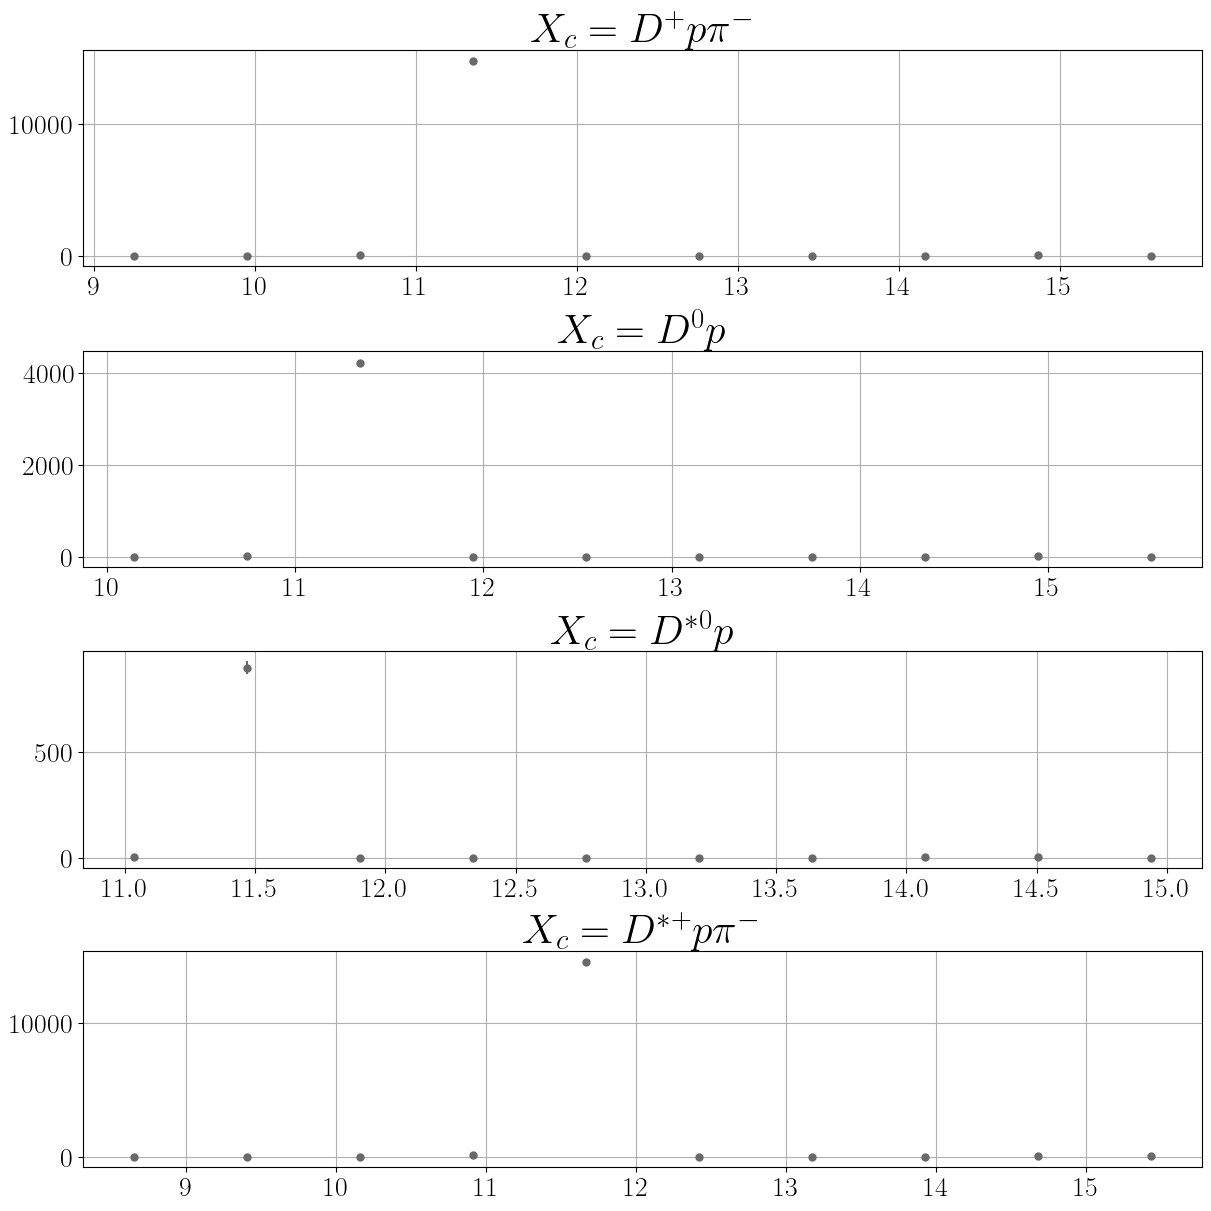

In [11]:
fig, axs = plt.subplots(4, figsize=(12, 12))
for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i) & (inc.IsSignalXc == 1) & (inc.IsS == 1)]
    N = dat.shape[0]
    counts, bin_centers = errorhist(dat.vphoE/2, axs = axs[ind])
    axs[ind].set_title(decay_mod_taging[ind])    
    axs[ind].grid()

plt.show()

/tmp/ipykernel_51455/2698801332.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_main.legend(title=decay_mod_taging[ind])


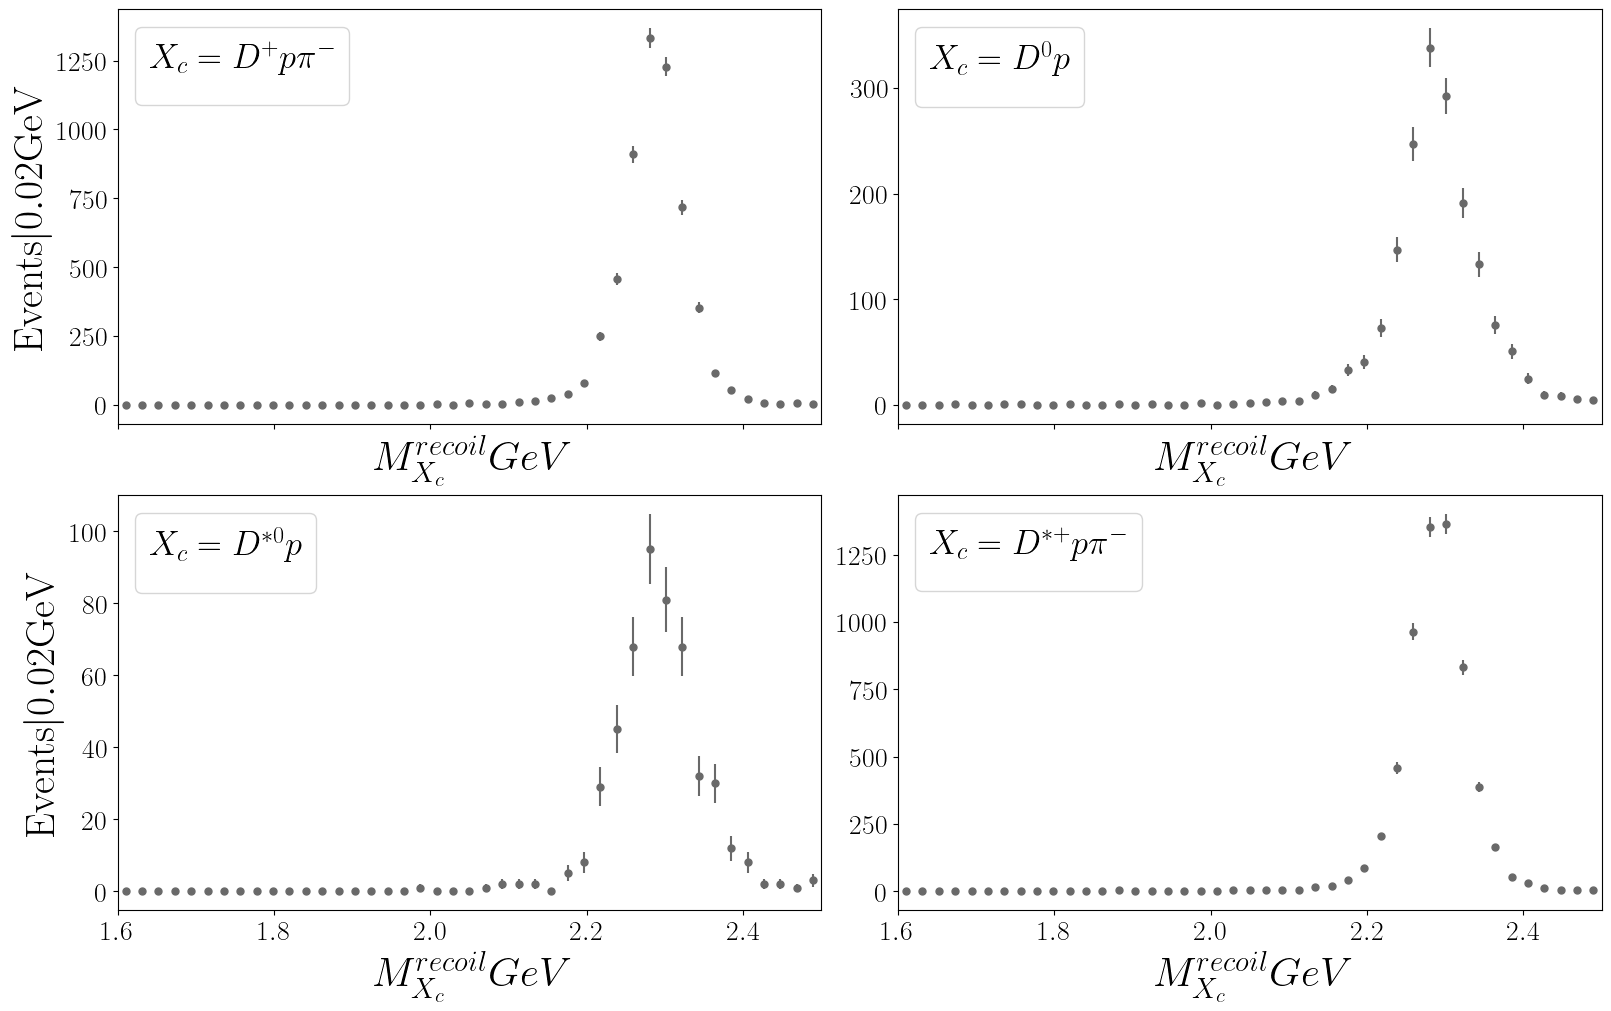

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(10*1.6, 10), sharex=True)
for ind, i in enumerate([1, 2, 3, 4]):
    ax_main = axs[ind//2, ind%2]
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i) & (inc.IsSignalXc == 1) & (inc.IsS == 1) & (abs(inc.vphoE/2 - inc.LambdaE - inc.XcE)<0.001)]
    N = dat.shape[0]
    counts, bin_centers = errorhist(dat.recM, bins=bins, axs = ax_main)
    #ax_main.grid()
    if ind%2 == 0:
        ax_main.set_ylabel(f'$\\mathrm{{Events}}| {wbin} \\mathrm{{GeV}}$')
    ax_main.set_xlabel('$M^{recoil}_{X_c}  GeV$')
    ax_main.set_xlim(a, b)
    ax_main.legend(title=decay_mod_taging[ind])


plt.show()

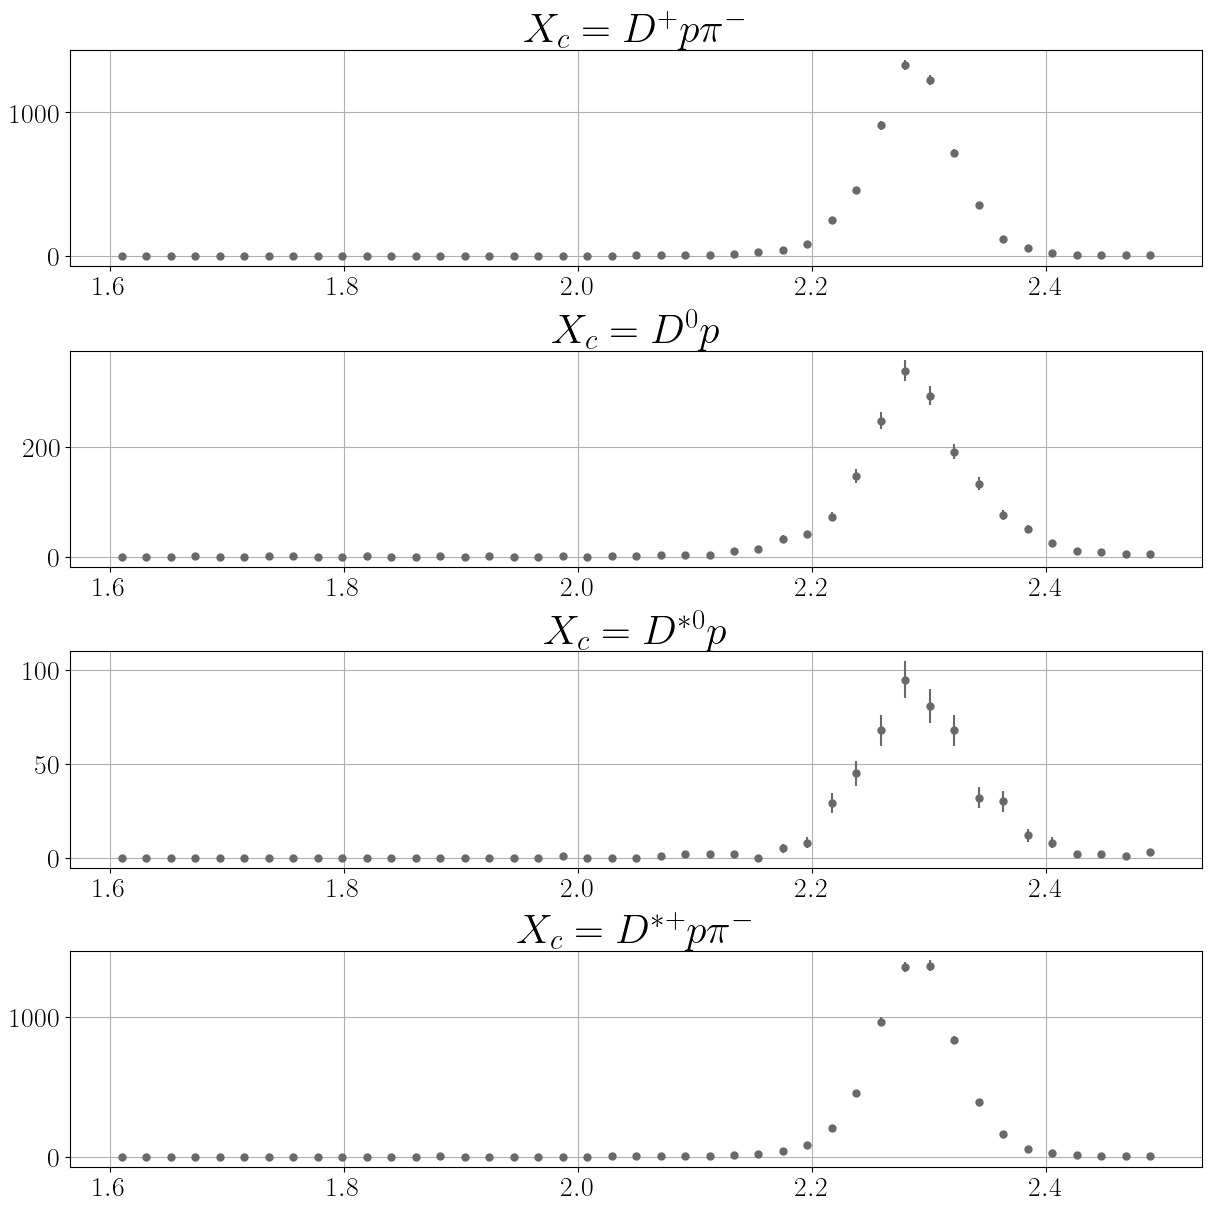

In [13]:
fig, axs = plt.subplots(4, figsize=(12, 12))
for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i) & (inc.IsSignalXc == 1) & (inc.IsS == 1) & (abs(inc.vphoE/2 - inc.LambdaE - inc.XcE)<0.001)]
    N = dat.shape[0]
    counts, bin_centers = errorhist(dat.recM, bins=bins, axs = axs[ind])
    axs[ind].set_title(decay_mod_taging[ind])    
    axs[ind].grid()

plt.show()

/tmp/ipykernel_51455/1900523417.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_main.legend(title=decay_mod_taging[i-1])


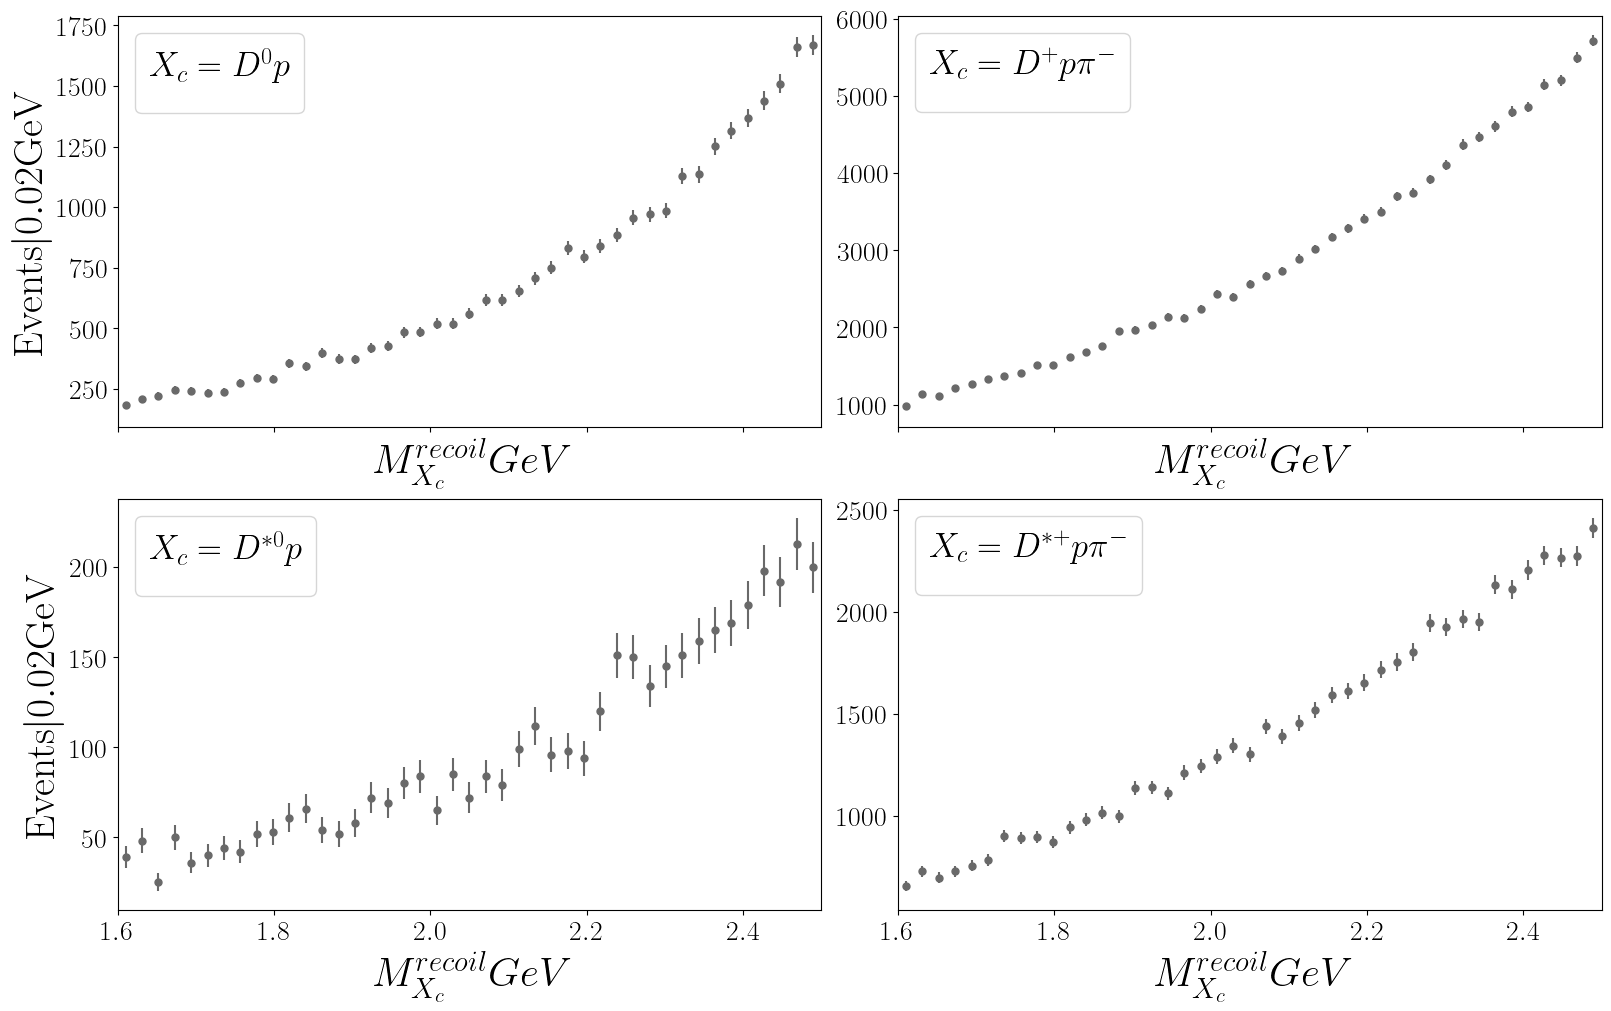

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(10*1.6, 10), sharex=True)
for ind, i in enumerate([2, 1, 3, 4]):
    ax_main = axs[ind//2, ind%2]
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i)  & (((inc.isPiFromLc == 1) | (inc.isPFromLc == 1)) & (abs(inc.vphoE/2 - inc.LambdaE - inc.XcE)>0.015) | (inc.IsSignalXc == 0))]
    N = dat.shape[0]
    counts, bin_centers = errorhist(dat.recM, bins=bins, axs = ax_main)
    #ax_main.grid()
    if ind%2 == 0:
        ax_main.set_ylabel(f'$\\mathrm{{Events}}| {wbin} \\mathrm{{GeV}}$')
    ax_main.set_xlabel('$M^{recoil}_{X_c}  GeV$')
    ax_main.set_xlim(a, b)
    ax_main.legend(title=decay_mod_taging[i-1])


plt.show()

/tmp/ipykernel_51455/2060827377.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_main.legend(title=decay_mod_taging[i-1])


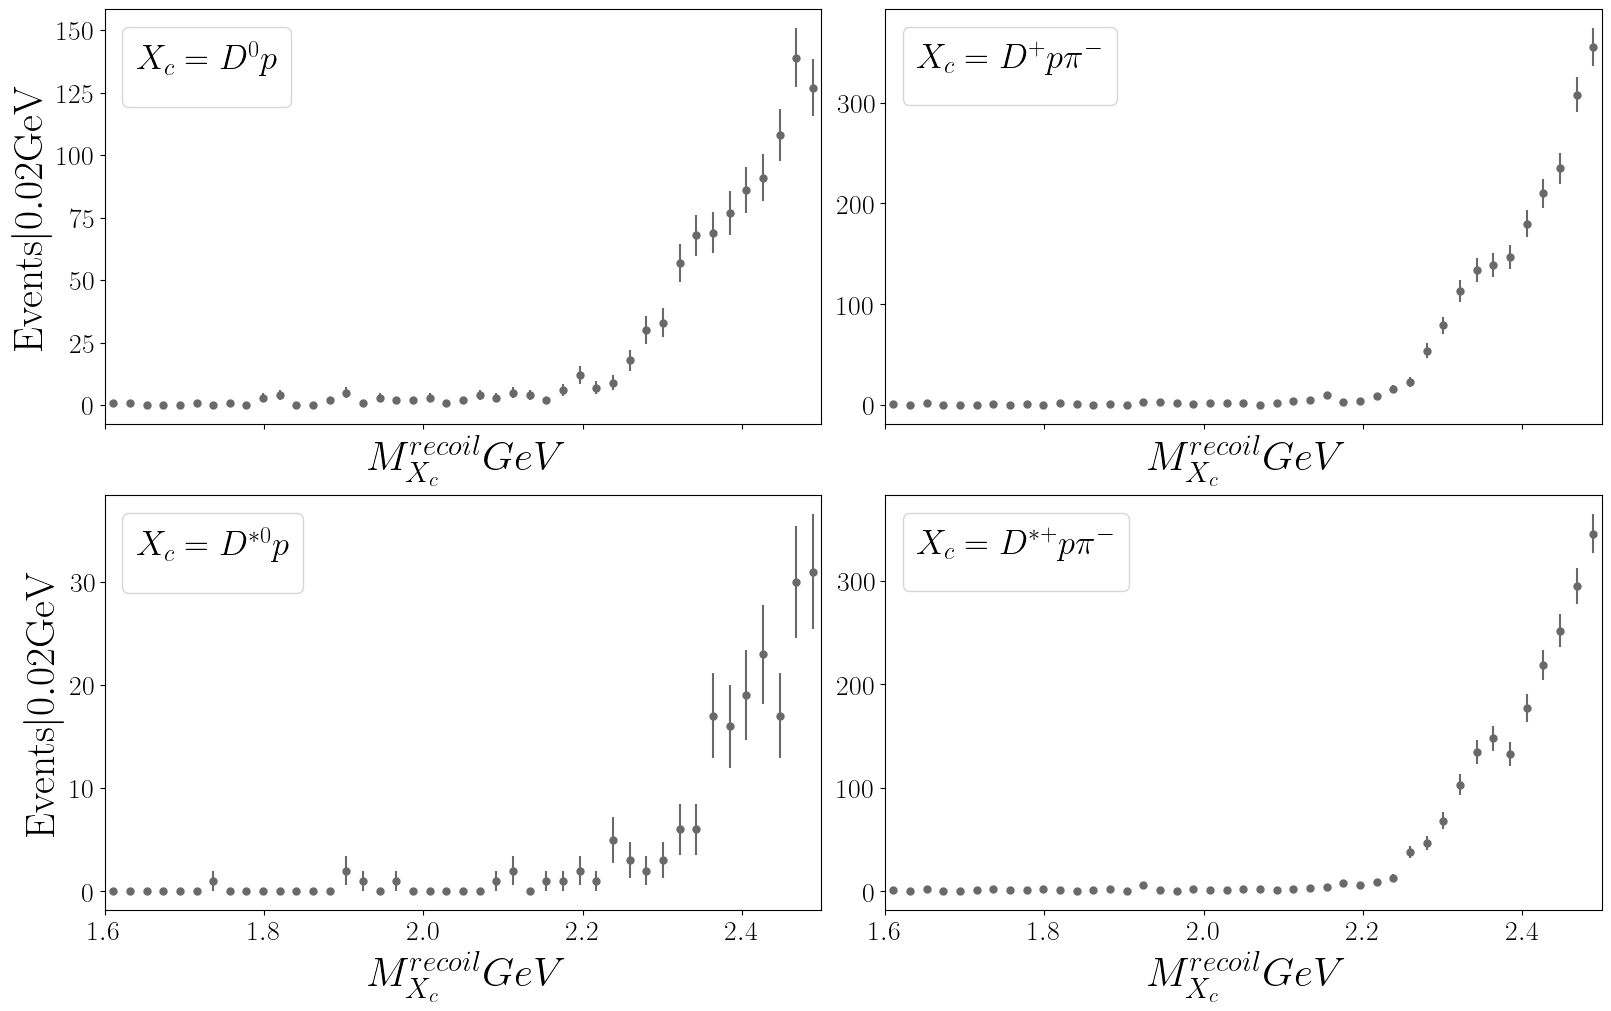

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(10*1.6, 10), sharex=True)
for ind, i in enumerate([2, 1, 3, 4]):
    ax_main = axs[ind//2, ind%2]
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i) & (inc.LC_miss == 1) & (abs(inc.vphoE/2 - inc.LambdaE - inc.XcE)>0.015)]
    N = dat.shape[0]
    counts, bin_centers = errorhist(dat.recM, bins=bins, axs = ax_main)
    #ax_main.grid()
    if ind%2 == 0:
        ax_main.set_ylabel(f'$\\mathrm{{Events}}| {wbin} \\mathrm{{GeV}}$')
    ax_main.set_xlabel('$M^{recoil}_{X_c}  GeV$')
    ax_main.set_xlim(a, b)
    ax_main.legend(title=decay_mod_taging[i-1])


plt.show()

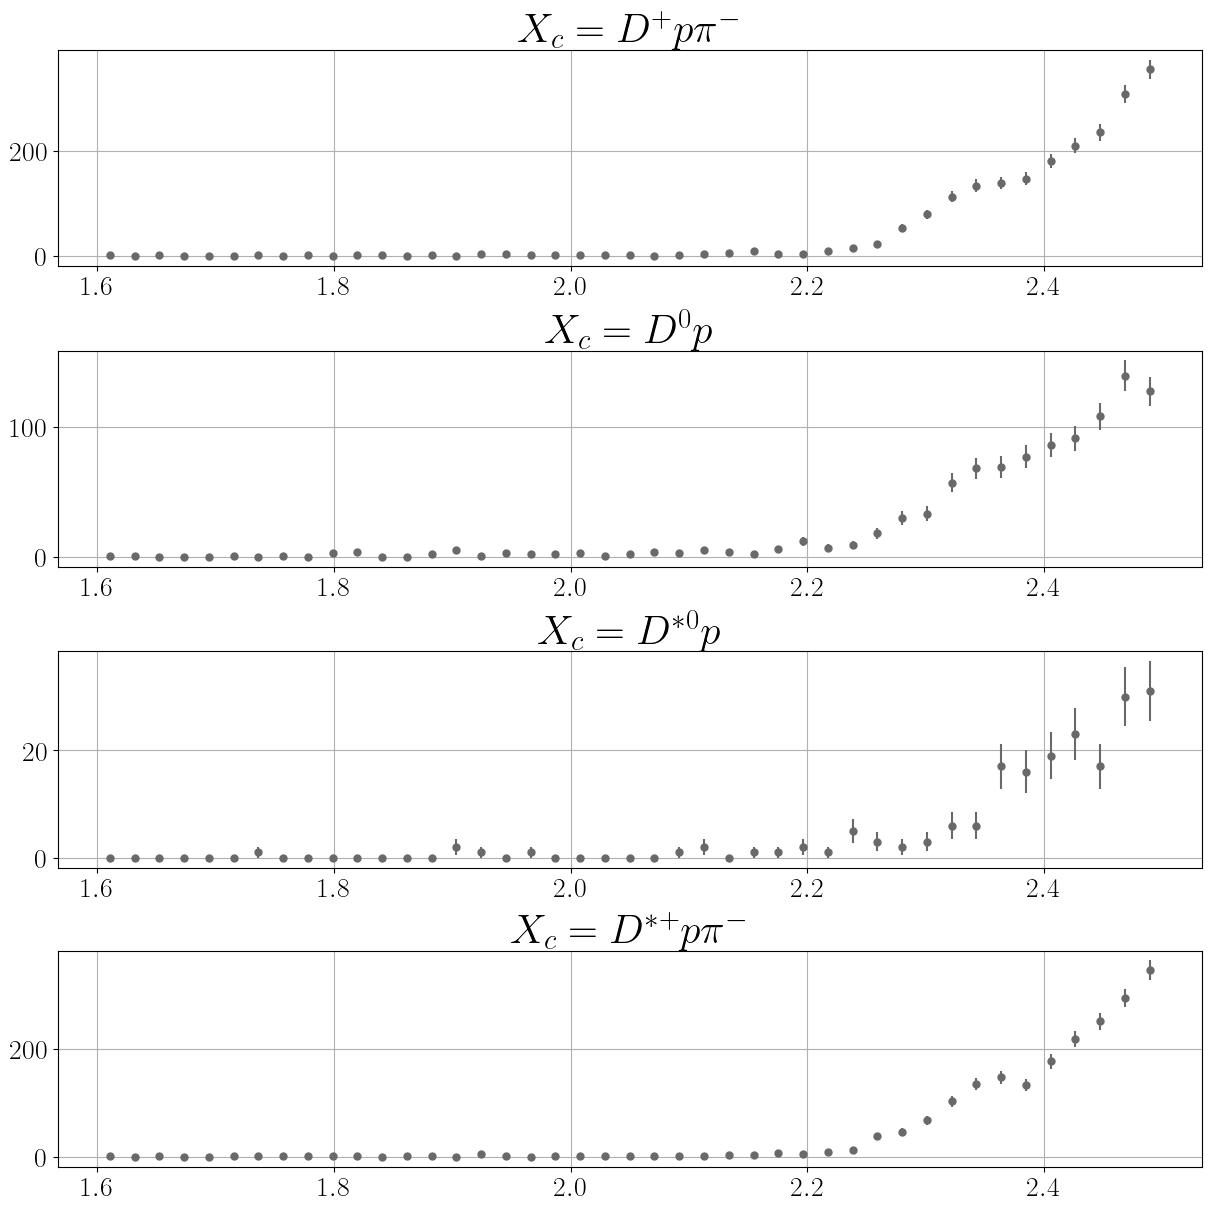

In [16]:
fig, axs = plt.subplots(4, figsize=(12, 12))
for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i) & (inc.LC_miss == 1) & (abs(inc.vphoE/2 - inc.LambdaE - inc.XcE)>0.015)]
    N = dat.shape[0]
    counts, bin_centers = errorhist(dat.recM, bins=bins, axs = axs[ind])
    axs[ind].set_title(decay_mod_taging[ind])    
    axs[ind].grid()

plt.show()

In [17]:
def max_bin_lik(f, bin_centers, counts, args0, wbin = 1, h=1e-7, bounds=None, normm=None, method='SLSQP'):
    normalization = np.max(counts)//10
    counts = counts/normalization
    norm = np.sum(counts)
    pdf = lambda bin_centers, norm, *args: f(bin_centers,*args)/(np.sum(f(bin_centers, *args)))*norm
    args0 = [norm,] + list(args0)
    if bounds != None:
        bounds = [(0, norm*100), ] + list(bounds)
    def df(*args0):
            return -np.sum(np.log(puasson(pdf(bin_centers, *args0), counts)))
    minuit = Minuit(df, *args0)
    minuit.migrad()
    rez = minuit.values
    norm = rez[0]*normalization
    print(rez)
    return rez[1:], pdf, norm

In [18]:
divi_g = njit(lambda x, mass1, mass2, A2, sigma1, sigma2: (A2*gaussian(x, mass1, sigma1) + (1-A2)*gaussian(x, mass2, sigma2)))
treis_g = njit(lambda x ,mass1, mass2, A1, A2, sigma1, sigma2, sigma3: (A2*gaussian(x, mass1, sigma1) + (1-A2)*gaussian(x, mass2, sigma2))*A1 + (1 - A1)*gaussian(x, Lamc_m, sigma3))

In [19]:
fitting_functions_s = [treis_g, treis_g, treis_g, treis_g]
initial_params_s = [[Lamc_m, Lamc_m, 0.5, 0.5, 0.03, 0.03, 0.03], [Lamc_m, Lamc_m, 0.5, 0.5, 0.03, 0.03, 0.03], 
                    [Lamc_m, Lamc_m, 0.5, 0.5, 0.03, 0.03, 0.03], [Lamc_m, Lamc_m, 0.5, 0.5, 0.03, 0.03, 0.03]]

In [20]:
def max_bin_lik(f, bin_centers, counts, args0, wbin = 1, h=1e-7, bounds=None, normm=None, method='SLSQP', err_need = False):
    normalization = np.max(counts)//10
    counts = counts/normalization
    norm = np.sum(counts)
    pdf = lambda x, norm, *args, bin_centers = None: f(x,*args)/(np.sum(f(x, *args)))*norm if bin_centers is None else f(x,*args)/(np.sum(f(bin_centers, *args)))*norm
    args0 = [norm,] + list(args0)
    if bounds != None:
        bounds = [(0, norm*100), ] + list(bounds)
    def df(*args0):
            return -np.sum(np.log(puasson(pdf(bin_centers, *args0), counts)))
    minuit = Minuit(df, *args0)
    minuit.migrad()
    rez = minuit.values
    norm = rez[0]*normalization
    print(rez)
    if err_need:
        return rez[1:], pdf, norm, minuit.errors[0]*normalization
    return rez[1:], pdf, norm


In [21]:
alis = ['a', 'b', 'c', 'd']

<ValueView x0=55.92683407886541 x1=2.300257400671305 x2=2.2906425275889606 x3=0.9692364698949189 x4=0.559738456677137 x5=0.06948702162756483 x6=0.032463554547890315 x7=0.3154971586850125>
<ValueView x0=47.13835785394038 x1=2.303706626650954 x2=2.0355899289031116 x3=0.2693608663736918 x4=0.9622750674833385 x5=0.07304952940481922 x6=0.13921719461090504 x7=0.032761965454685356>
<ValueView x0=63.200003319569426 x1=2.3440219816979755 x2=2.293414485061136 x3=0.9895525559580699 x4=0.14968401350176144 x5=0.13217101711945048 x6=0.0445331044020073 x7=0.36592348023848204>
<ValueView x0=45.900587283864404 x1=2.3081381908894953 x2=2.0616506344555767 x3=0.3179246260674139 x4=0.972920765920143 x5=0.06571820663574954 x6=0.1394064314309808 x7=0.03120058461753931>


/tmp/ipykernel_51455/3408321526.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_main.legend(title=alis[ind])


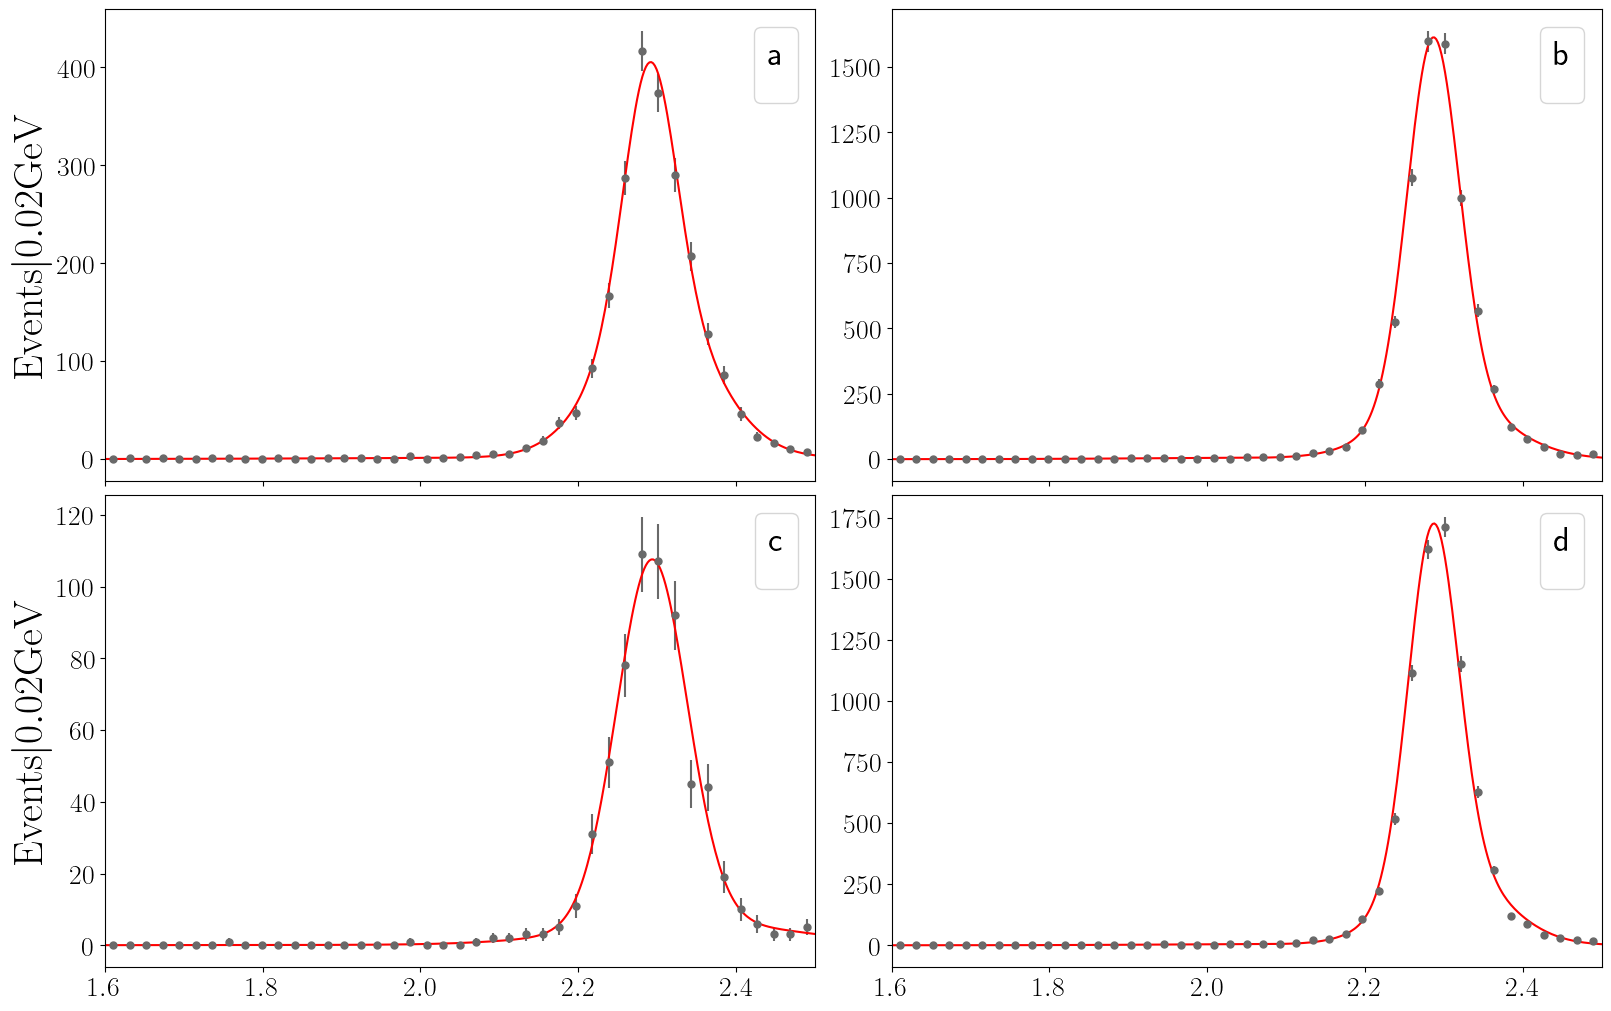

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(10*1.6, 10), sharex=True)

sig_params_dir = os.path.join(params_dir, 'sig')
sig_pdf_dir = os.path.join(pdf_dir, 'sig')
os.makedirs(sig_params_dir, exist_ok=True)
os.makedirs(sig_pdf_dir, exist_ok=True)
params_dict = {}

save = True

for ind, i in enumerate([2, 1, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i) & (inc.IsSignalXc == 1) & (abs(inc.vphoE/2 - inc.LambdaE - inc.XcE)<0.02) & ((inc.isPiFromLc == 0) | (inc.isPFromLc == 0))]
    ax_main = axs[ind//2, ind%2]
    counts, bin_centers = errorhist(dat.recM, bins=bins, color='dimgrey', axs=ax_main)      
    
    N = dat.shape[0]
    f_sig = fitting_functions_s[i-1]
    args = initial_params_s[i-1]

    initial_params_s[i-1], pdf, norm = max_bin_lik(f_sig, bin_centers, counts, args, wbin = wbin)

    if ind%2 == 0:
        ax_main.set_ylabel(f'$\\mathrm{{Events}}| {wbin} \\mathrm{{GeV}}$')

    args =  [norm, *initial_params_s[i-1]]; f_sig = pdf
    title = decay_mod_taging[i-1]
    x = np.linspace(a, b, 400)
    expected = f_sig(bin_centers, *args)
    chi2 = np.sum(((counts - expected)**2) / (np.where(counts == 0, 1, counts)))
    ax_main.plot(x, f_sig(x, *args, bin_centers=bin_centers), color = 'red')

    #ax_main.set_title(title)
    if ind%2 == 0:
        ax_main.set_ylabel(f'$\\mathrm{{Events}}| {wbin} \\mathrm{{GeV}}$')

    ax_main.set_xlim(a, b)
    ax_main.legend(title=alis[ind])


<ValueView x0=47.13836674947546 x1=2.2930879417367325 x2=2.371363927818395 x3=0.6597087821797285 x4=0.8893574849137065 x5=0.0477657629920027 x6=0.22668130274488935 x7=0.02469351201222414>
<ValueView x0=55.92683299523798 x1=2.300271281575633 x2=2.290655109499604 x3=0.9691340335006956 x4=0.5596627773135805 x5=0.06953729156185567 x6=0.03240959544573311 x7=0.31553531418718356>
<ValueView x0=63.20000220658449 x1=2.331630705019747 x2=2.2934286226995053 x3=0.9869768972098987 x4=0.16100864049875938 x5=0.12632109896051216 x6=0.04412001805378524 x7=1.0246799731518519>
<ValueView x0=45.90058770122787 x1=2.2964789240548256 x2=2.380415164714787 x3=0.6769886950903782 x4=0.8879007143862672 x5=0.0451125413329767 x6=0.20340961387007114 x7=0.025224279703657152>


/tmp/ipykernel_51455/3344105442.py:43: RuntimeWarning: divide by zero encountered in divide
  ax_resid.plot(bin_centers, residuals / np.sqrt(counts), '.', color='lightcoral')


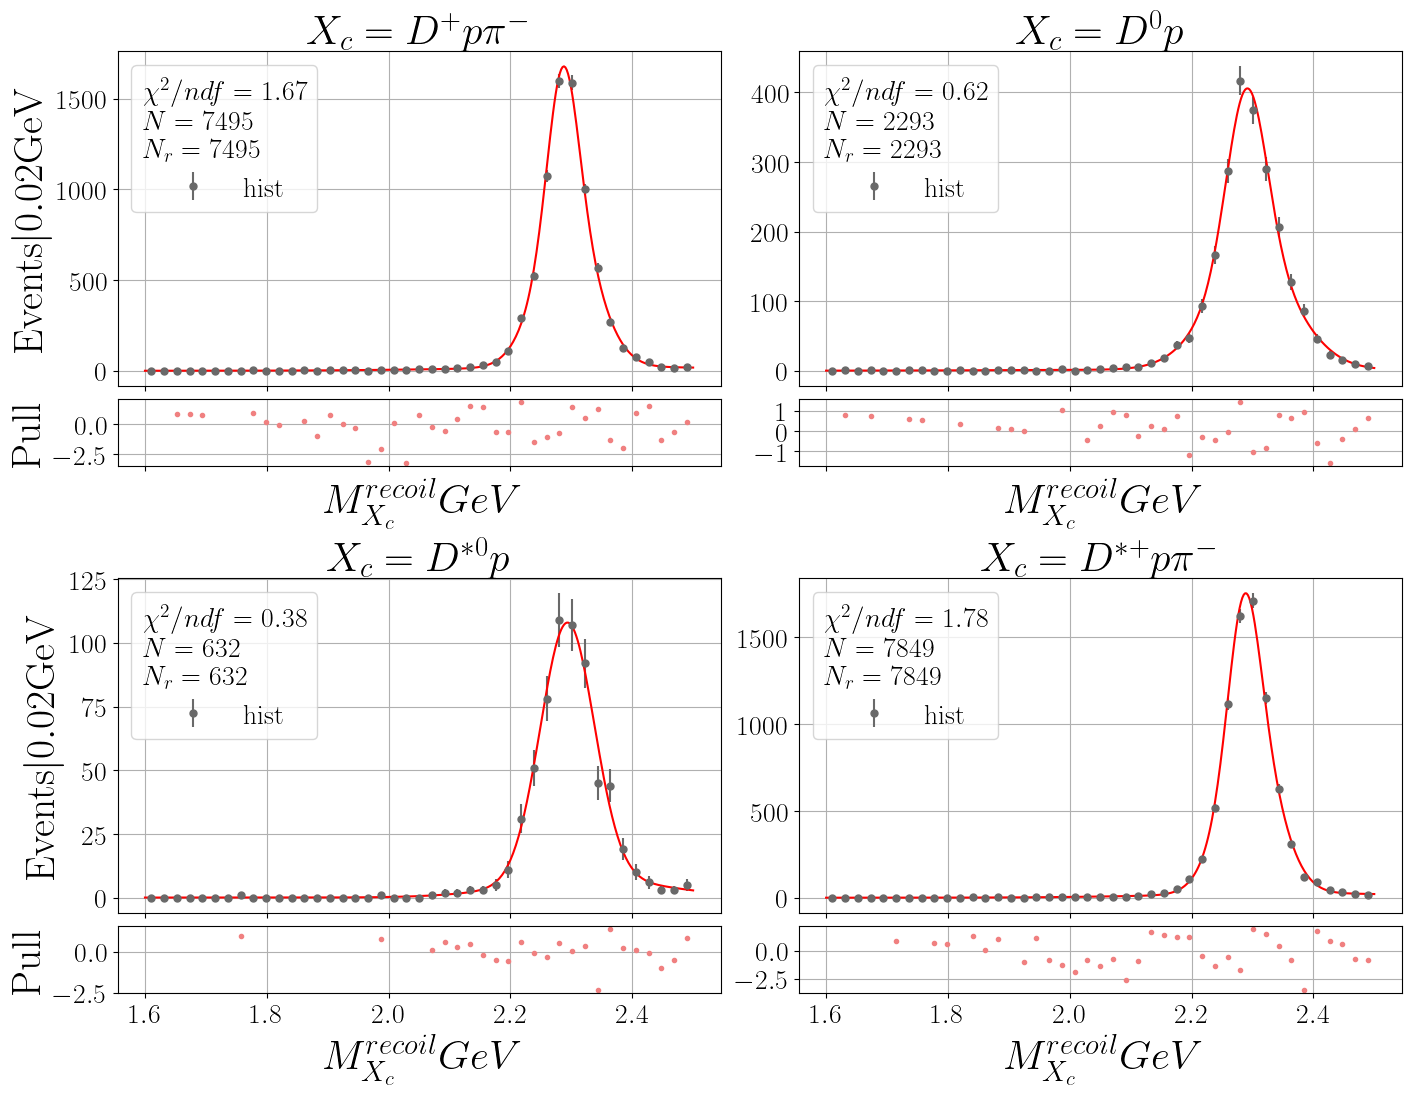

In [25]:
fig, axs = plt.subplots(4, 2, figsize=(14, 26*2/1.6/3), gridspec_kw={'height_ratios': [1, 0.2]*2}, sharex=True)

sig_params_dir = os.path.join(params_dir, 'sig')
sig_pdf_dir = os.path.join(pdf_dir, 'sig')
os.makedirs(sig_params_dir, exist_ok=True)
os.makedirs(sig_pdf_dir, exist_ok=True)
params_dict = {}

save = True

for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i) & (inc.IsSignalXc == 1) & (abs(inc.vphoE/2 - inc.LambdaE - inc.XcE)<0.02) & ((inc.isPiFromLc == 0) | (inc.isPFromLc == 0))]
    counts, bin_centers = errorhist(dat.recM, bins=bins, color='dimgrey', label="$\\mathrm{hist}$", axs=axs[ind//2 * 2, ind%2 ])      
    
    N = dat.shape[0]
    f_sig = fitting_functions_s[ind]
    args = initial_params_s[ind]

    ax_main = axs[ind//2 * 2, ind%2]
    initial_params_s[ind], pdf, norm = max_bin_lik(f_sig, bin_centers, counts, args, wbin = wbin)

    args =  [norm, *initial_params_s[ind]]; f_sig = pdf
    title = decay_mod_taging[i-1]

    expected = f_sig(bin_centers, *args)
    chi2 = np.sum(((counts - expected)**2) / (np.where(counts == 0, 1, counts)))
    ax_main.plot(x, f_sig(x, *args, bin_centers=bin_centers), color = 'red')

    ax_main.set_title(title)
    if ind%2 == 0:
        ax_main.set_ylabel(f'$\\mathrm{{Events}}| {wbin} \\mathrm{{GeV}}$')
    ax_main.grid()

    ax_main.legend(title=f"$\\chi^2/ndf = {chi2/(int((b-a)/wbin)-len(args)):.2f}$ \n $N = {norm:.0f}$\n $N_r = {np.sum(counts)}$",
                    fontsize=20, 
                    title_fontsize=20)

    if save:
        params_dict[i] = {'initial_params': initial_params_s[ind], 'norm': norm}

    residuals = counts - f_sig(bin_centers, *args)
    ax_resid = axs[ind//2 * 2 + 1, ind%2 ]
    ax_resid.plot(bin_centers, residuals / np.sqrt(counts), '.', color='lightcoral')
    ax_resid.set_xlabel('$M^{recoil}_{X_c}  GeV$')
    if ind%2 == 0:
        ax_resid.set_ylabel('$\\mathrm{Pull}$')
    ax_resid.set_xlim(ax_main.get_xlim()) 
    ax_resid.grid()
plt.savefig(path("MC_sig_fit.png"), format = "png")


In [26]:
for ind, i in enumerate([1, 2, 3, 4]):
    with open(os.path.join(sig_params_dir, f'params_{i}.json'), 'w') as f:
        json.dump(params_dict[i], f, indent=4)
    with open(os.path.join(sig_pdf_dir, f'pdf_{i}.pkl'), 'wb') as f:
        dill.dump(fitting_functions_s[ind], f)

In [27]:
def convolution_meshed(x, g, f, fargs, gargs, delta = 0.1, N = 1000, mesh = None):
    # Оптимизированная функция поиска свертки двух функций опреденных на x
    # Условие применимости 
    # f - синальная функция на X и локализованная в центре X, пик узкий (хотя он может быть не один) если нет то надо расширить S
    # g - функция фонов, определена на S - mean(X)
    # S содержит X-mean(X) так чтобы for all xi in (X-mean(X))/S, x' in x => f(xi-x) << 1
    # Кароче s = [min(x)-delta, max(x)+delta] где delta полуширина пика   
    mu = np.mean(x)
    if not(mesh is None):
        N = mesh.shape[0]
        x, s = np.meshgrid(x, mesh)
    else:
        x, s = np.meshgrid(x, np.linspace(np.min(x) - mu - delta, np.max(x) - mu + delta, N))
    return np.sum(g(s, *fargs)*f(x-s, *gargs), axis=0)/N

In [28]:
sq = njit(lambda x, c1, c2: c1 * np.sqrt((x - Pi_0_m) * heaviside(x, Pi_0_m))  + c2 * np.sqrt(x * heaviside(x, 0)))
def continuum_lam(i, x, c1, c2):
    return (convolution_meshed(x, sq, fitting_functions_s[i], [c1, c2], list([1,])+initial_params_s[i][1:], mesh=np.linspace(-0.4, 0.4, 1000)))


fitting_functions_c = [lambda x, c1, c2: continuum_lam(i, x, c1, c2) for i in range(4)]
initial_params_c = [[2.2, 0.01], [3, 9], [2, 7], [2.2, 0.01]]
bounds_c = [
    [(0,100), (0,100)],
    [(0,100), (0,100)],
    [(0,100), (0,100)],
    [(0,100), (0,100)],]


<ValueView x0=53.34286059207999 x1=3.3230876384884936e-05 x2=6.315512056110682e-05>
<ValueView x0=70.61538681035992 x1=3.0916807334570513 x2=8.679402013481141>
<ValueView x0=60.666671233011584 x1=2.1146775363498866 x2=1.9106602710074412>
<ValueView x0=53.55882712584065 x1=3.6613346277575316e-05 x2=2.6114606062035215e-05>


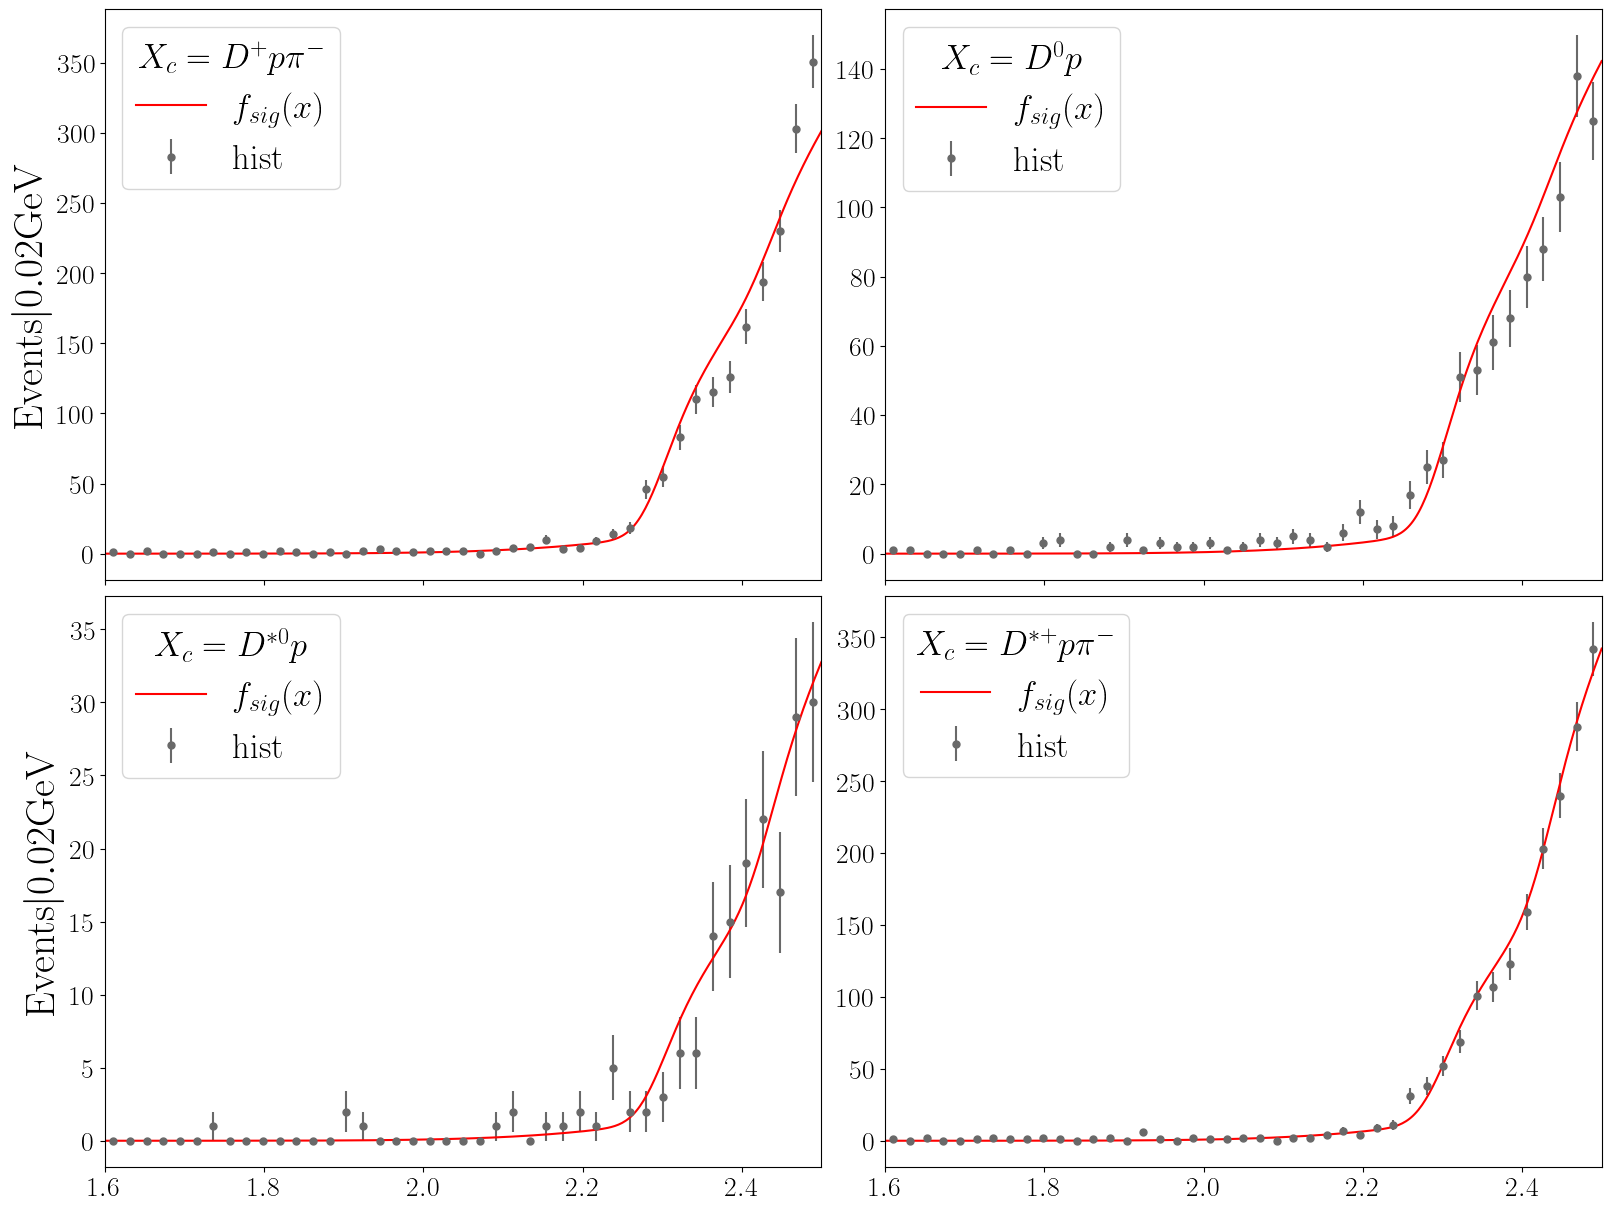

In [29]:
fig, axs = plt.subplots(2, 2, figsize=(10*1.6, 10*1.2), sharex=True)

sig_params_dir = os.path.join(params_dir, 'sig')
sig_pdf_dir = os.path.join(pdf_dir, 'sig')
os.makedirs(sig_params_dir, exist_ok=True)
os.makedirs(sig_pdf_dir, exist_ok=True)
params_dict = {}

save = True

for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i) & (inc.LC_miss == 1) & (inc.IsSignalXc == 1) & (abs(inc.vphoE/2 - inc.LambdaE - inc.XcE)>0.02)]
    ax_main = axs[ind//2, ind%2]
    counts, bin_centers = errorhist(dat.recM, bins=bins, color='dimgrey', label="$\\mathrm{hist}$", axs=ax_main)      
    
    N = dat.shape[0]
    f_sig = fitting_functions_c[ind]
    args = initial_params_c[ind]

    initial_params_c[ind], pdf, norm  = max_bin_lik(f_sig, bin_centers, counts, initial_params_c[ind], bounds=bounds_c[ind], wbin = wbin)

    args =  [norm, *initial_params_c[ind]]; f_sig = pdf
    title = decay_mod_taging[i-1]
    x = np.linspace(a, b, 400)
    expected = f_sig(bin_centers, *args)
    chi2 = np.sum(((counts - expected)**2) / (np.where(counts == 0, 1, counts)))
    ax_main.plot(x, f_sig(x, *args, bin_centers=bin_centers), label="$f_{sig}(x)$", color = 'red')

    if ind%2 == 0:
        ax_main.set_ylabel(f'$\\mathrm{{Events}}| {wbin} \\mathrm{{GeV}}$')

    ax_main.set_xlim(a, b)
    ax_main.legend(title=title)


<ValueView x0=52.371429935213605 x1=3.0158864438771274e-05 x2=2.0082063739424212e-05>
<ValueView x0=67.00000219322007 x1=3.0734835217561023 x2=5.963746752640538>
<ValueView x0=58.3333364046628 x1=2.2428464525727523 x2=1.738344852362739>
<ValueView x0=52.58823747265526 x1=3.9181646336010086e-05 x2=2.294342898468585e-05>


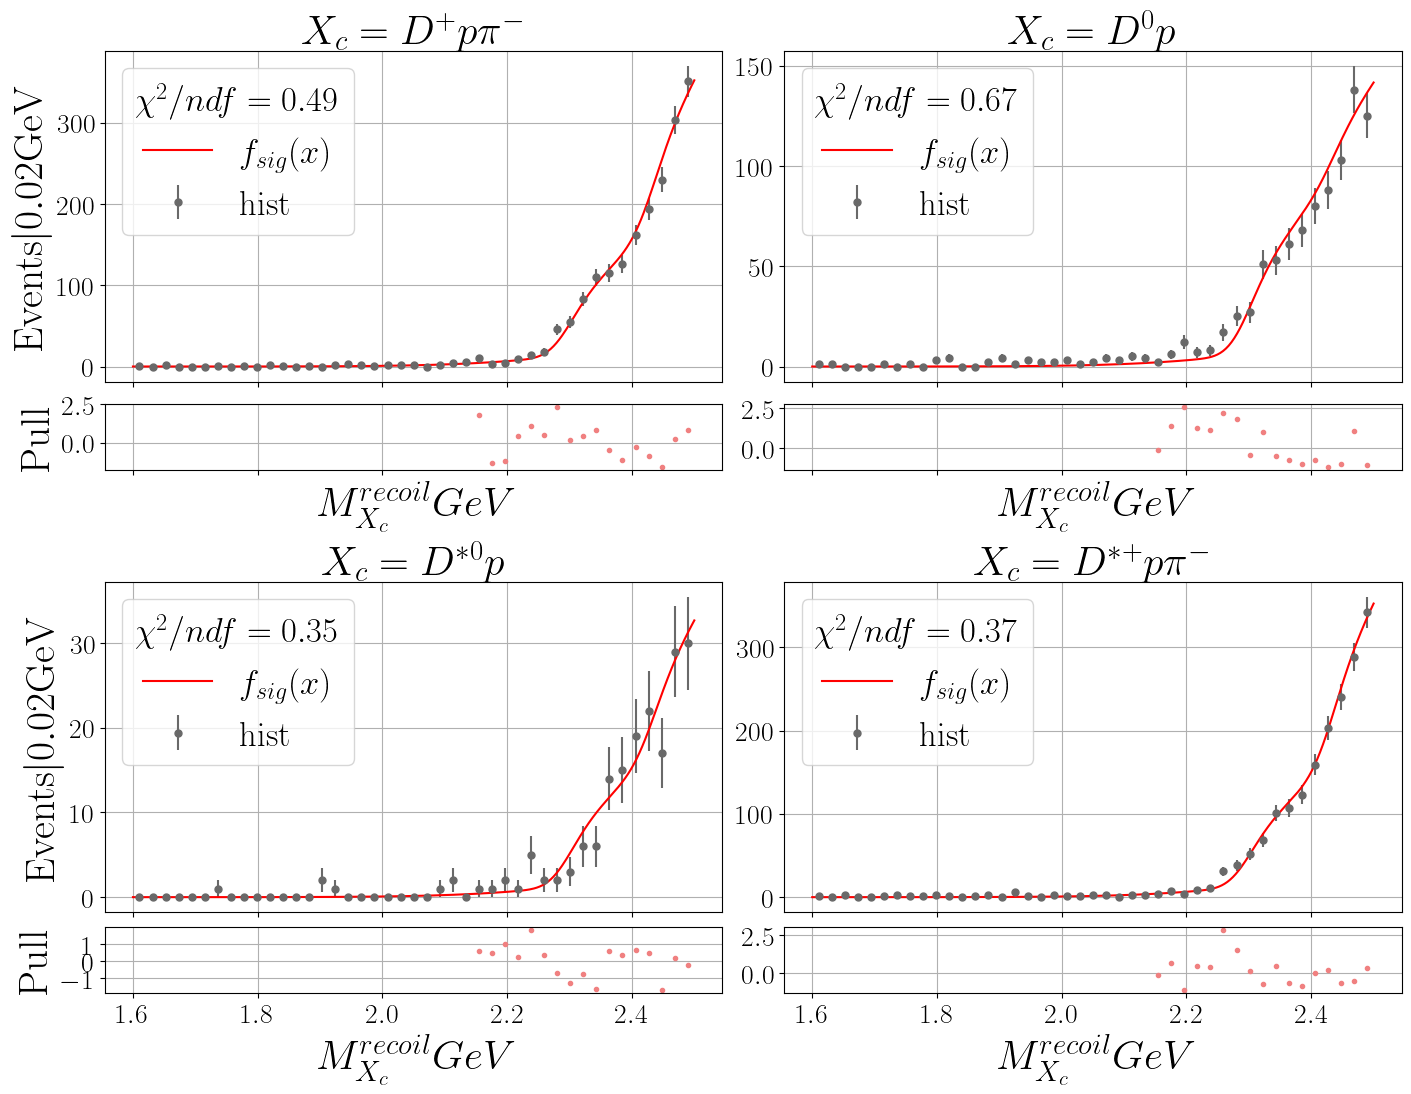

In [30]:
fig, axs = plt.subplots(4, 2, figsize=(14, 26*2/1.6/3), gridspec_kw={'height_ratios': [1, 0.2]*2}, sharex=True)

c_params_dir = os.path.join(params_dir, 'c')
c_pdf_dir = os.path.join(pdf_dir, 'c')
c_bounds_dir = os.path.join(bounds_dir, 'c')
os.makedirs(c_params_dir, exist_ok=True)
os.makedirs(c_bounds_dir, exist_ok=True)
os.makedirs(c_pdf_dir, exist_ok=True)
params_dict = {}

for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i) & (inc.LC_miss == 1) & (inc.IsSignalXc == 1) & (abs(inc.vphoE/2 - inc.LambdaE - inc.XcE)>0.02)]
    counts, bin_centers = errorhist(dat.recM, bins=bins, color='dimgrey', label="$\\mathrm{hist}$", axs=axs[ind//2 * 2, ind%2 ])      
    counts = counts[bin_centers > Lamc_m-0.15]
    bin_centers = bin_centers[bin_centers > Lamc_m-0.15]
    f_sig = fitting_functions_c[ind]
    args = initial_params_c[ind]

    ax_main = axs[ind//2 * 2, ind%2]
    initial_params_c[ind], pdf, norm  = max_bin_lik(f_sig, bin_centers, counts, initial_params_c[ind], bounds=bounds_c[ind], wbin = wbin)

    args =  [norm, *initial_params_c[ind]]; f_sig = pdf
    title = decay_mod_taging[i-1]

    expected = f_sig(bin_centers, *args)
    chi2 = np.sum(((counts - expected)**2) / (np.where(counts == 0, 1, counts)))
    ax_main.plot(x, f_sig(x, *args, bin_centers=bin_centers), label="$f_{sig}(x)$", color = 'red')

    ax_main.set_title(title)
    if ind%2 == 0:
        ax_main.set_ylabel(f'$\\mathrm{{Events}}| {wbin} \\mathrm{{GeV}}$')
    ax_main.grid()

    ax_main.legend(title=f"$\\chi^2/ndf = {chi2/(int((b-a)/wbin)-len(args)):.2f}$")

    if save:
        params_dict[i] = {'initial_params': initial_params_c[ind], 'norm': norm}

    residuals = counts - f_sig(bin_centers, *args)
    ax_resid = axs[ind//2 * 2 + 1, ind%2 ]
    ax_resid.plot(bin_centers, residuals / np.sqrt(counts), '.', color='lightcoral')
    ax_resid.set_xlabel('$M^{recoil}_{X_c}  GeV$')
    if ind%2 == 0:
        ax_resid.set_ylabel('$\\mathrm{Pull}$')
    ax_resid.set_xlim(ax_main.get_xlim()) 

    ax_resid.grid()

plt.savefig(path("MC_sqr_bg_fit.png"), format = "png")


In [31]:
if save:
    for ind, i in enumerate([1, 2, 3, 4]):
        with open(os.path.join(c_params_dir, f'params_{i}.json'), 'w') as f:
            json.dump(params_dict[i], f, indent=4)
        with open(os.path.join(c_bounds_dir, f'bounds_{i}.json'), 'w') as f:
            json.dump(bounds_c[i-1], f, indent=4)
        def __f__(x, c1, c2):
            return continuum_lam(i-1, x, c1, c2)
        with open(os.path.join(c_pdf_dir, f'pdf_{i}.pkl'), 'wb') as f:
            dill.dump(__f__, f)

In [32]:
continuum_lam = njit(lambda x, lam, mu, c0, c1: (exp_dis(x - mu, lam) + c0 + c1*eval_chebyt(1, x - Lamc_m)))

fitting_functions_bg = [continuum_lam, continuum_lam, continuum_lam, continuum_lam]
initial_params_bg = [[2, 1, -0.002, -0.02], [1.5, 1, -0.0002, -0.02], [1.5, 1, -0.0002, -0.02], [1.5, 1, -0.0002, -0.02]]

<ValueView x0=214.70395430517584 x1=1.7035831196538647 x2=1.724115644721534 x3=-0.042383740617144734 x4=0.17834465359917248>
<ValueView x0=178.22155122676648 x1=2.4664960403417364 x2=-4.008601029411504 x3=-1387.2480116352294 x4=-12414.17467458622>
<ValueView x0=201.6666746977557 x1=2.172135366606919 x2=-6.517883523173373 x3=-8799837.618942242 x4=-20494232.37277935>


/tmp/ipykernel_51455/669610319.py:5: RuntimeWarning: invalid value encountered in divide
  pdf = lambda x, norm, *args, bin_centers = None: f(x,*args)/(np.sum(f(x, *args)))*norm if bin_centers is None else f(x,*args)/(np.sum(f(bin_centers, *args)))*norm
/tmp/ipykernel_51455/669610319.py:10: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(puasson(pdf(bin_centers, *args0), counts)))


<ValueView x0=253.5353059993319 x1=1.1740360595432666 x2=0.5642389095088195 x3=0.07596952211050803 x4=1.159108077206024>


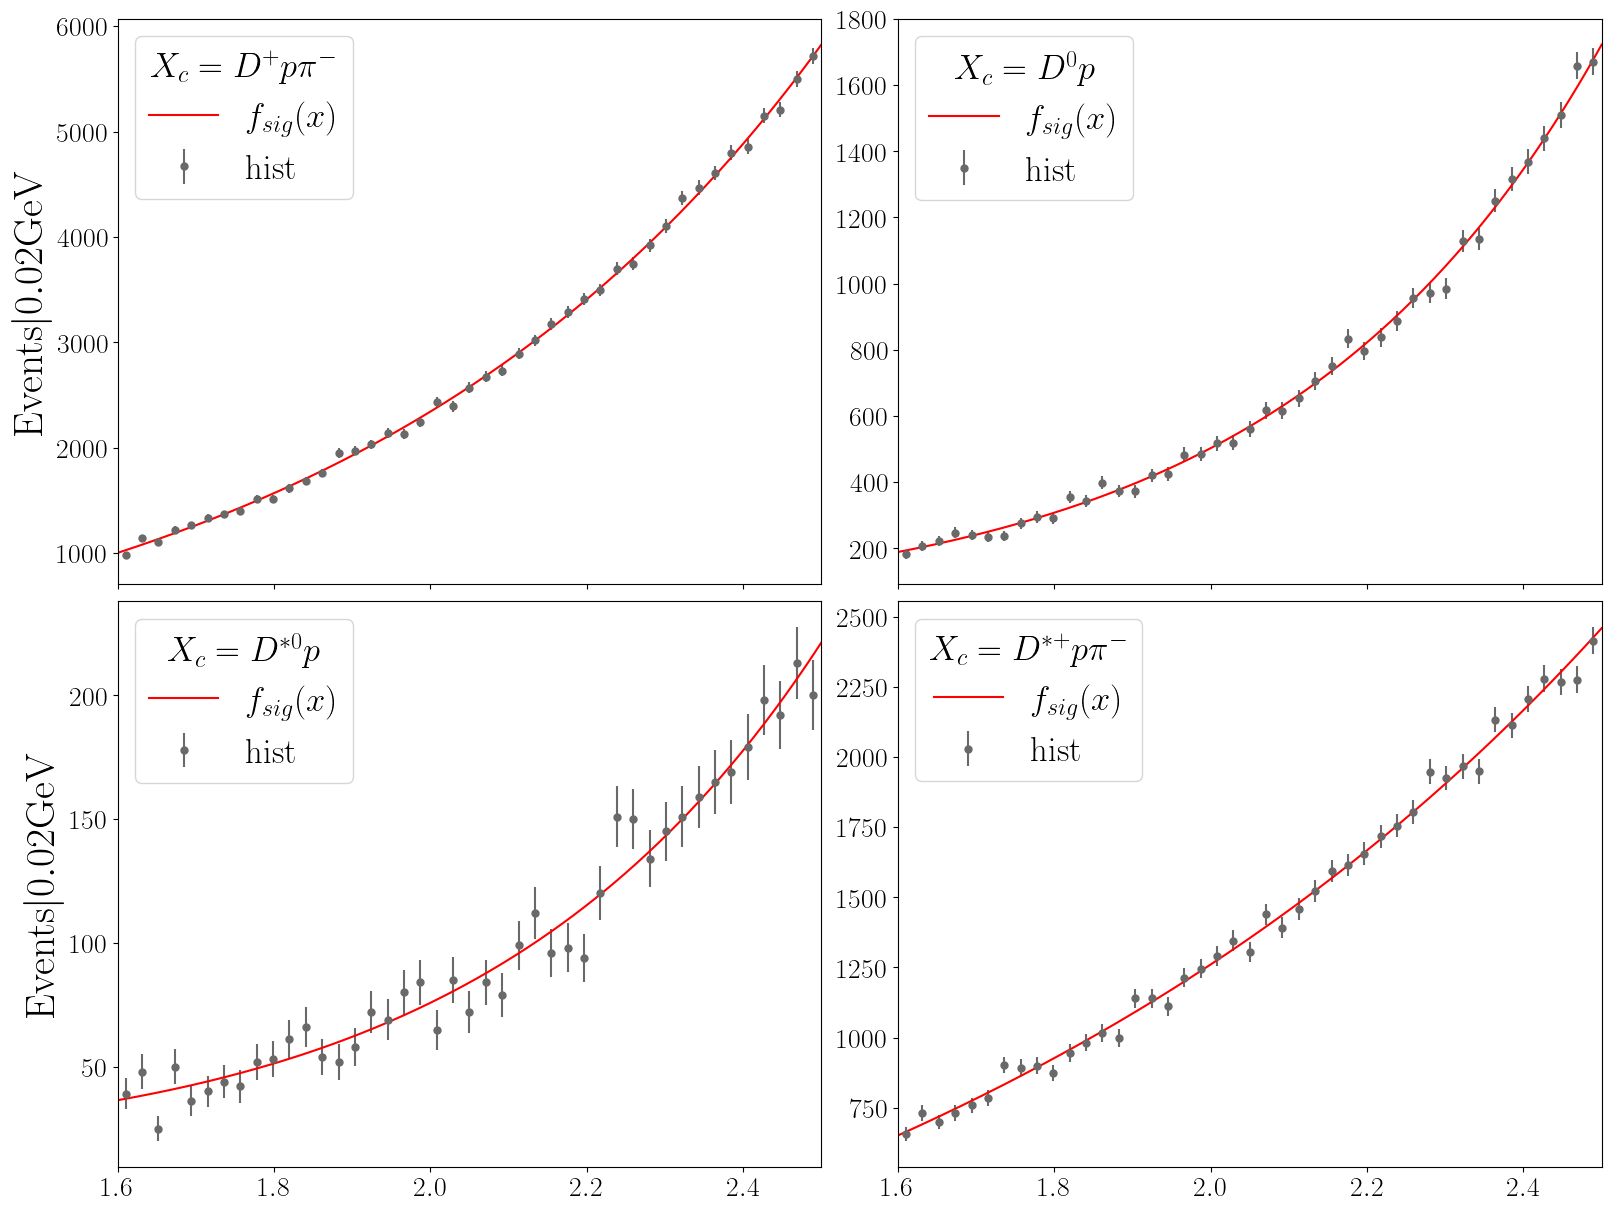

In [33]:
fig, axs = plt.subplots(2, 2, figsize=(10*1.6, 10*1.2), sharex=True)

sig_params_dir = os.path.join(params_dir, 'sig')
sig_pdf_dir = os.path.join(pdf_dir, 'sig')
os.makedirs(sig_params_dir, exist_ok=True)
os.makedirs(sig_pdf_dir, exist_ok=True)
params_dict = {}

save = True

for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i)  & (((inc.isPiFromLc == 1) | (inc.isPFromLc == 1)) & (abs(inc.vphoE/2 - inc.LambdaE - inc.XcE)>0.015) | (inc.IsSignalXc == 0))]
    ax_main = axs[ind//2, ind%2]
    counts, bin_centers = errorhist(dat.recM, bins=bins, color='dimgrey', label="$\\mathrm{hist}$", axs=ax_main)      
    
    N = dat.shape[0]


    f_sig = fitting_functions_bg[ind]; args = initial_params_bg[ind]
    initial_params_bg[ind], pdf, norm = max_bin_lik(f_sig, bin_centers, counts, args, wbin = wbin)
    args = [norm, *initial_params_bg[ind]]; f_sig = pdf; title = decay_mod_taging[i-1]
    
    args =  [norm, *initial_params_bg[ind]]; f_sig = pdf
    title = decay_mod_taging[i-1]
    x = np.linspace(a, b, 400)
    expected = f_sig(bin_centers, *args)
    chi2 = np.sum(((counts - expected)**2) / (np.where(counts == 0, 1, counts)))
    ax_main.plot(x, f_sig(x, *args, bin_centers=bin_centers), label="$f_{sig}(x)$", color = 'red')

    if ind%2 == 0:
        ax_main.set_ylabel(f'$\\mathrm{{Events}}| {wbin} \\mathrm{{GeV}}$')
    ax_main.set_xlim(a, b)

    ax_main.legend(title=title)


<ValueView x0=214.704033007367 x1=1.7037111102368703 x2=1.7239352648177995 x3=-0.04243315862659788 x4=0.17823782796103385>
<ValueView x0=178.22155864980994 x1=2.4886849326095 x2=-3.8934353167295663 x3=6573.609314001841 x4=-33252.30709339165>
<ValueView x0=201.6667245484089 x1=2.134456355327417 x2=-6.627195054447484 x3=-12952542.94107564 x4=-22542683.625652265>
<ValueView x0=253.53527421471088 x1=1.1717495678678163 x2=0.5659115606209312 x3=0.07520198867146223 x4=1.1611214586487613>


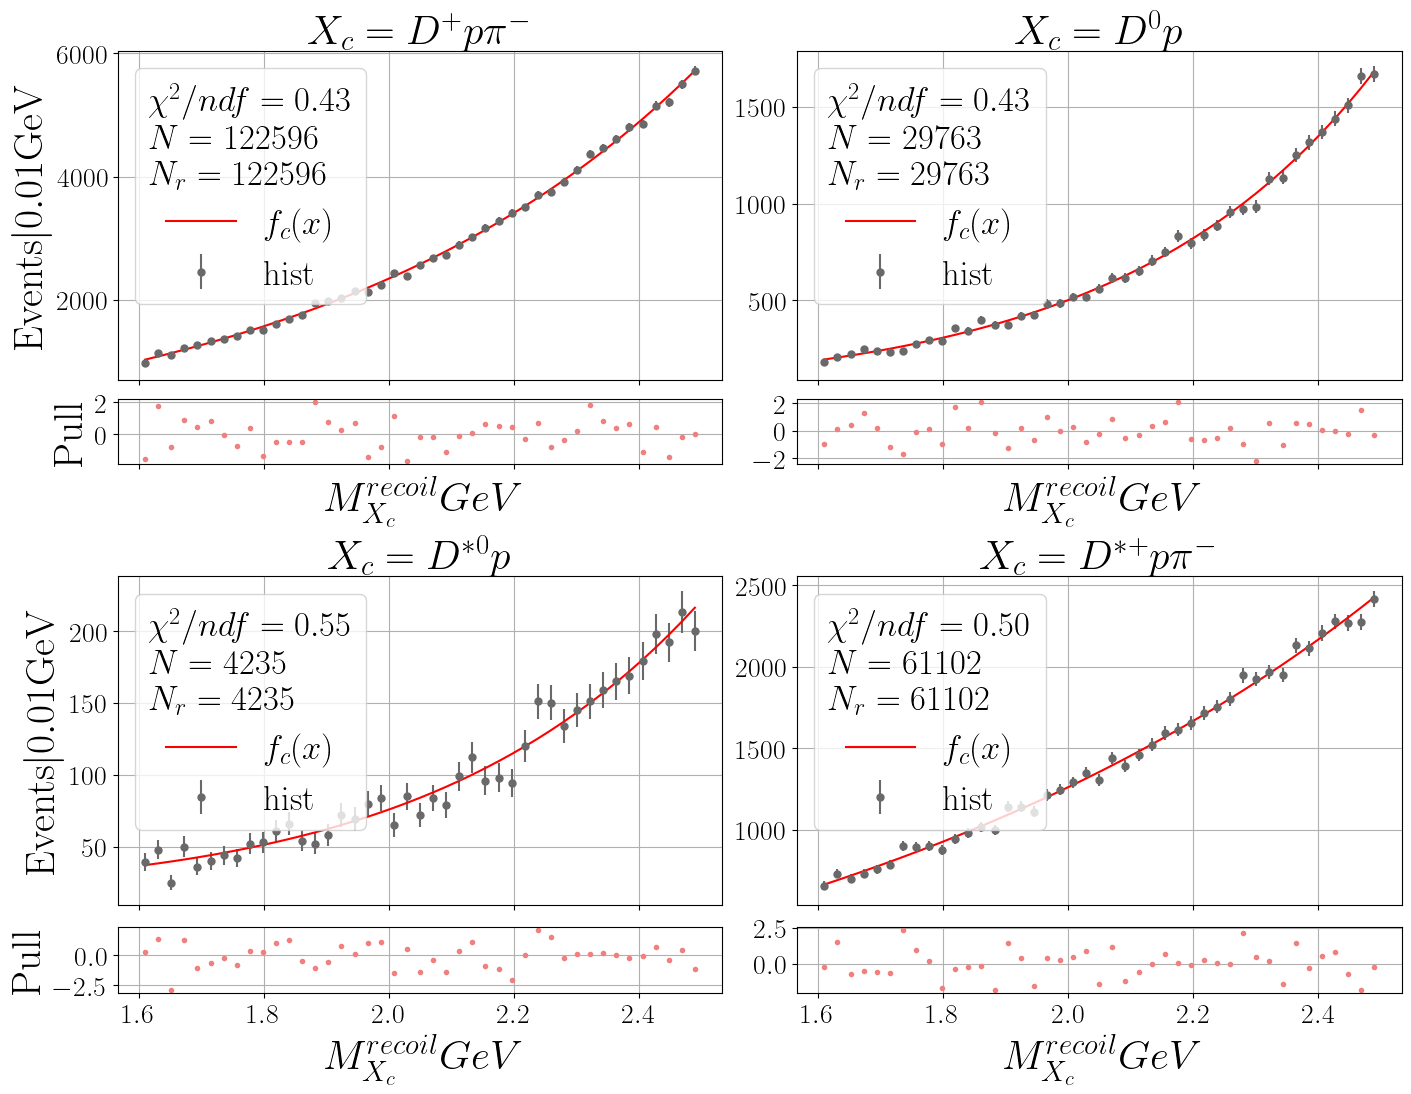

In [38]:
fig, axs = plt.subplots(4, 2, figsize=(14, 26*2/1.6/3), gridspec_kw={'height_ratios': [1, 0.2]*2}, sharex=True)

bg_params_dir = os.path.join(params_dir, 'bg')
bg_pdf_dir = os.path.join(pdf_dir, 'bg')
os.makedirs(bg_params_dir, exist_ok=True)
os.makedirs(bg_pdf_dir, exist_ok=True)
params_dict = {}

for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i)  & (((inc.isPiFromLc == 1) | (inc.isPFromLc == 1)) & (abs(inc.vphoE/2 - inc.LambdaE - inc.XcE)>0.015) | (inc.IsSignalXc == 0))]
    counts, bin_centers = errorhist(dat.recM, bins=bins, color='dimgrey', label="$\\mathrm{hist}$", axs=axs[ind//2 * 2, ind%2 ])      

    f_sig = fitting_functions_bg[ind]; args = initial_params_bg[ind]; ax_main = axs[ind//2 * 2, ind%2]
    initial_params_bg[ind], pdf, norm = max_bin_lik(f_sig, bin_centers, counts, args, wbin = wbin)
    args = [norm, *initial_params_bg[ind]]; f_sig = pdf; title = decay_mod_taging[i-1]

    expected = f_sig(bin_centers, *args)
    chi2 = np.sum(((counts - expected)**2) / (np.where(counts == 0, 1, counts)))
    ax_main.plot(bin_centers, f_sig(bin_centers, *args), label=f"$f_c(x)$", color = 'red')

    ax_main.set_title(title)
    if ind%2 == 0:
        ax_main.set_ylabel(f'$\\mathrm{{Events}}| {wbin} \\mathrm{{GeV}}$')
    ax_main.grid()

    ax_main.legend(title=f"$\\chi^2/ndf = {chi2/(int((b-a)/wbin)-len(args)):.2f}$ \n $N = {norm:.0f}$\n $N_r = {np.sum(counts)}$")

    if save:
        params_dict[i] = {'initial_params': initial_params_bg[ind], 'norm': norm}

    residuals = counts - f_sig(bin_centers, *args)
    ax_resid = axs[ind//2 * 2 + 1, ind%2 ]
    ax_resid.plot(bin_centers, residuals / np.sqrt(counts), '.', color='lightcoral')
    ax_resid.set_xlabel('$M^{recoil}_{X_c}  GeV$')
    if ind%2 == 0:
        ax_resid.set_ylabel('$\\mathrm{Pull}$')
    ax_resid.set_xlim(ax_main.get_xlim()) 
    ax_resid.grid()
plt.savefig(path("MC_comb_fit.png"), format = "png")


In [39]:
for ind, i in enumerate([1, 2, 3, 4]):
    with open(os.path.join(bg_params_dir, f'params_{i}.json'), 'w') as f:
        json.dump(params_dict[i], f, indent=4)
    with open(os.path.join(bg_pdf_dir, f'pdf_{i}.pkl'), 'wb') as f:
        dill.dump(fitting_functions_bg[ind], f)

In [36]:
f_lam = lambda x, A1, mass1, A2, sigma1, sigma2, c0, c1, c2, b1, a1: A1*signal_lam(x, mass1, A2, sigma1, sigma2) + (1-A1)*continuum_lam(x, mass1, A2, sigma1, sigma2, c0, c1, c2, b1, a1)

NameError: name 'signal_lam' is not defined

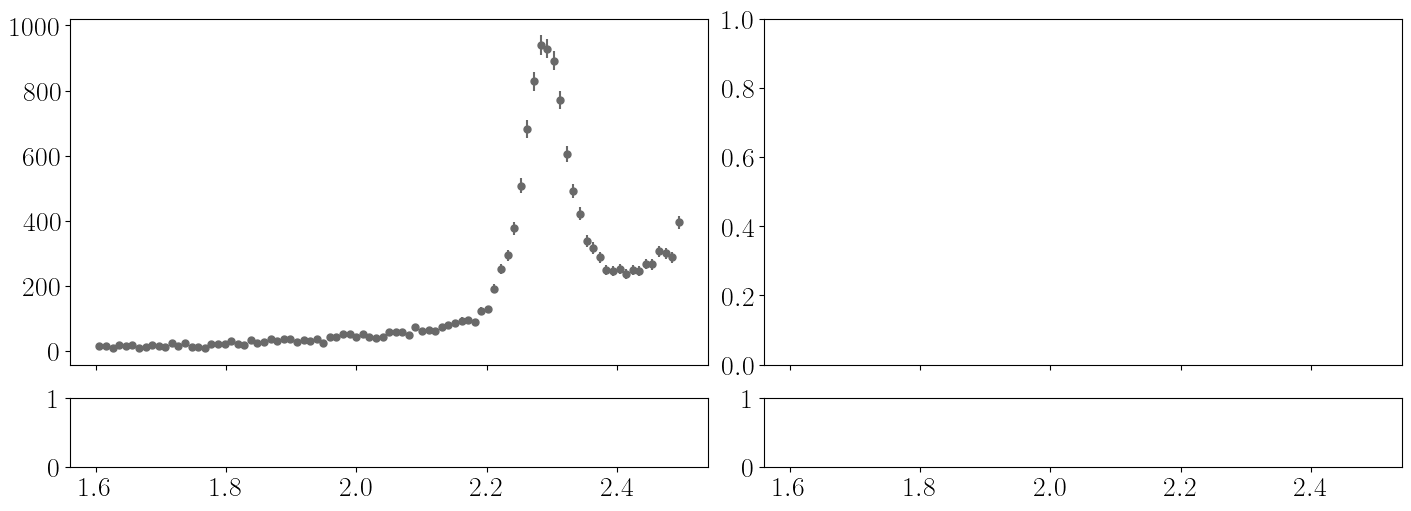

In [37]:
wbin = 0.01

fig, axs = plt.subplots(2, 2, figsize=(14, 12*2/1.6/3), gridspec_kw={'height_ratios': [1, 0.2]}, sharex=True)

for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.recM < b) & (inc.recM > a) & (inc.idec == i) & (inc.IsSignalXc == 1)]   
    counts, bin_centers = errorhist(dat.recM, bins=int((b-a)/wbin), color='dimgrey', label="$\\mathrm{hist}$", axs=axs[ind//2 * 2, ind%2 ])      
    N = dat.shape[0]

    args = (2.5e-01, Lamc_m, 0.1, 1e-02, 1e-02, 1e-01, 5e-01, 5e-01, 0, 0)
    bounds = ((0, 1), (Lamc_m - 0.05, Lamc_m + 0.05), (0.0001, 0.2), (0.0001, 0.2), (-10, 10), (-10, 10), (-10, 10), (-10, 10), (-10, 10), (-10, 10))

    ax_main = axs[ind//2 * 2, ind%2 ]
    args, _ = max_bin_lik(f_lam, bin_centers, counts, args, bounds = bounds)
    title = decay_mod_taging[i]
    expected = f_lam(bin_centers, *args)
    norm = N * wbin
    chi2 = np.sum(((expected*norm - counts)**2) / (counts))
    A1, mass1, A2, sigma1, sigma2, c0, c1, c2, b1, a1 = args
    ax_main.plot(bin_centers, (1-A1)*continuum_lam(bin_centers, mass1, A2, sigma1, sigma2, c0, c1, c2, b1, a1)* norm, label='$f_{continuum}$', linestyle='--')    
#    ax_main.vlines(Lamc_m, f_lam(Lamc_m, *args)*norm, 0)
    ax_main.plot(bin_centers, f_lam(bin_centers, *args)*norm, label=f"$F(x)$", color = 'red')
    ax_main.set_title(title)
    if ind%2 == 0:
        ax_main.set_ylabel(f'$\\mathrm{{Events}}| {wbin} \\mathrm{{GeV}}$')
    ax_main.grid()


    ax_main.legend(title=f"$N = {int(args[0]*N)} | {N}$ \n $\\sigma = {1000*args[4]:.0f} MeV$ \n $\\chi^2/ndf = {chi2/(int((b-a)/wbin)-len(args)):.2f}$")

    residuals = counts - f_lam(bin_centers, *args) * norm
    ax_resid = axs[ind//2 * 2 + 1, ind%2 ]
    ax_resid.plot(bin_centers, residuals / np.sqrt(counts), '.', color='lightcoral')
    ax_resid.set_xlabel('$M^{recoil}_{X_c}  GeV$')
    if ind%2 == 0:
        ax_resid.set_ylabel('\\mathrm{Pull}')
    ax_resid.set_xlim(ax_main.get_xlim()) 
    ax_resid.grid()
    


In [6]:
a = 1.6
b = 2.6
continuum_lam = njit(lambda x, A1, lam, mu, sig1, c0, c1, c2, c3, c4: A1*exp_dis(x - mu, lam, a - mu, b - mu) + (1-A1)*gaussian(x, 2.65, sig1) + c0*eval_chebyt(0, x - Lamc_m, a - Lamc_m, b - Lamc_m) + c1*eval_chebyt(1, x - Lamc_m, a - Lamc_m, b - Lamc_m) + c2*eval_chebyt(2, x - Lamc_m, a - Lamc_m, b - Lamc_m) + c3*eval_chebyt(3, x - Lamc_m, a - Lamc_m, b - Lamc_m) + c4*eval_chebyt(4, x - Lamc_m, a - Lamc_m, b - Lamc_m)) 
f_lam = lambda x, A, A1, lam, mu, sig, sig1, c0, c1, c2, c3, c4: A*gaussian(x, Lamc_m, sig) + (1-A)*continuum_lam(x, A1, lam, mu, sig1, c0, c1, c2, c3, c4)

In [ ]:
wbin = 0.01

fig, axs = plt.subplots(2, 2, figsize=(14, 12*2/1.6/3), gridspec_kw={'height_ratios': [1, 0.2]}, sharex=True)

for ind, i in enumerate([(1, 2), (3, 4)]):
    dat = inc[(inc.rm < b) & (inc.rm > a) & (inc.ntr <= 3) & (inc.chxc.isin(i)) & (
              ((inc.chxc >= 3) & (np.abs(inc.dsm - inc.dm - 0.142014) < 0.003)) |
              ((inc.chxc <= 2) & (np.abs(inc.dm - D_0_m) < 0.015)))]    
    counts, bin_centers = errorhist(dat.rm, bins=int((b-a)/wbin), color='dimgrey', label="$\\mathrm{hist}$", axs=axs[ind//2 * 2, ind%2 ])      
    N = dat.shape[0]

    bounds = [(0, 1), (0, 1), (1, 2), (-1, 3), (0.0001, 0.1), (0.0001, 0.2), (-0.2, 0.15), (-0.15, 0.15), (-1e-2, 0.15), (-1e-3, 1e-3), (-1e-3, 1e-3)]
    if ind == 0:
        args = (1.5e-02, 0.99, 1.5, 1, 0.05, 0.15, -4.5e-05, 0, 0, 0, 0)
    else:
        args = (0.03, 0.97, 1.5, 1, 0.07, 0.15, -1e-5, 0, 0, 0, 0)

    ax_main = axs[ind//2 * 2, ind%2 ]
    args, _ = max_bin_lik(f_lam, bin_centers, counts, args, bounds = bounds)
    title = str(' $ \& $ '.join([decay_mod_taging[_-1] for _ in i]))
    expected = f_lam(bin_centers, *args)
    norm = N * wbin
    chi2 = np.sum(((expected*norm - counts)**2) / (counts))
    A, A1, lam, mu, sig, sig1, c0, c1, c2, c3, c4 = args
    ax_main.plot(bin_centers, (1-A)*continuum_lam(bin_centers, A1, lam, mu, sig1, c0, c1, c2, c3, c4)* norm, label='$f_{continuum}$', linestyle='--')    
#    ax_main.vlines(Lamc_m, f_lam(Lamc_m, *args)*norm, 0)
    ax_main.plot(bin_centers, f_lam(bin_centers, *args)*norm, label=f"$F(x)$", color = 'red')
    ax_main.set_title(title)
    if ind%2 == 0:
        ax_main.set_ylabel(f'$\\mathrm{{Events}}| {wbin} \\mathrm{{GeV}}$')
    ax_main.grid()


    ax_main.legend(title=f"$N = {int(args[0]*N)} | {N}$ \n $\\sigma = {1000*args[4]:.0f} MeV$ \n $\\chi^2/ndf = {chi2/(int((b-a)/wbin)-len(args)):.2f}$")

    residuals = counts - f_lam(bin_centers, *args) * norm
    ax_resid = axs[ind//2 * 2 + 1, ind%2 ]
    ax_resid.plot(bin_centers, residuals / np.sqrt(counts), '.', color='lightcoral')
    ax_resid.set_xlabel('$M^{recoil}_{X_c}  GeV$')
    if ind%2 == 0:
        ax_resid.set_ylabel('\\mathrm{Pull}')
    ax_resid.set_xlim(ax_main.get_xlim()) 
    ax_resid.grid()
    


In [ ]:
wbin = 0.01

fig, axs = plt.subplots(2, 4, figsize=(14, 12*2/1.6/3), gridspec_kw={'height_ratios': [1, 0.2]}, sharex=True)

for ind, i in enumerate([1, 2, 3, 4]):
    dat = inc[(inc.rm < b) & (inc.rm > a) & (inc.ntr <= 3) & (inc.chxc == i) & (
              ((inc.chxc >= 3) & (np.abs(inc.dsm - inc.dm - 0.142014) < 0.003)) |
              ((inc.chxc <= 2) & (np.abs(inc.dm - D_0_m) < 0.015)))]    
    counts, bin_centers = errorhist(dat.rm, bins=int((b-a)/wbin), color='dimgrey', label="$\\mathrm{hist}$", axs=axs[ind//2 * 2, ind%2 ])      
    N = dat.shape[0]

    bounds = [(0, 1), (0, 1), (1, 2), (-1, 3), (0.0001, 0.1), (0.0001, 0.2), (-0.2, 0.15), (-0.15, 0.15), (-1e-2, 0.15), (-1e-3, 1e-3), (-1e-3, 1e-3)]
    if ind == 0:
        args = (1.5e-02, 0.99, 1.5, 1, 0.05, 0.15, -4.5e-05, 0, 0, 0, 0)
    else:
        args = (0.03, 0.97, 1.5, 1, 0.07, 0.15, -1e-5, 0, 0, 0, 0)

    ax_main = axs[ind, 0 ]
    args, _ = max_bin_lik(f_lam, bin_centers, counts, args, bounds = bounds)
    title = decay_mod_taging[i]
    expected = f_lam(bin_centers, *args)
    norm = N * wbin
    chi2 = np.sum(((expected*norm - counts)**2) / (counts))
    A, A1, lam, mu, sig, sig1, c0, c1, c2, c3, c4 = args
    ax_main.plot(bin_centers, (1-A)*continuum_lam(bin_centers, A1, lam, mu, sig1, c0, c1, c2, c3, c4)* norm, label='$f_{continuum}$', linestyle='--')    
#    ax_main.vlines(Lamc_m, f_lam(Lamc_m, *args)*norm, 0)
    ax_main.plot(bin_centers, f_lam(bin_centers, *args)*norm, label=f"$F(x)$", color = 'red')
    ax_main.set_title(title)
    if ind%2 == 0:
        ax_main.set_ylabel(f'$\\mathrm{{Events}}| {wbin} \\mathrm{{GeV}}$')
    ax_main.grid()


    ax_main.legend(title=f"$N = {int(args[0]*N)} | {N}$ \n $\\sigma = {1000*args[4]:.0f} MeV$ \n $\\chi^2/ndf = {chi2/(int((b-a)/wbin)-len(args)):.2f}$")

    residuals = counts - f_lam(bin_centers, *args) * norm
    ax_resid = axs[ind, 1]
    ax_resid.plot(bin_centers, residuals / np.sqrt(counts), '.', color='lightcoral')
    ax_resid.set_xlabel('$M^{recoil}_{X_c}  GeV$')
    if ind%2 == 0:
        ax_resid.set_ylabel('\\mathrm{Pull}')
    ax_resid.set_xlim(ax_main.get_xlim()) 
    ax_resid.grid()
    
